# Part B — Designing an MPC Controller

**ES4G4 Assignment 1 (Python rebuild)** · This notebook covers **B-1**: the full
mathematical formulation of the linear MPC and every design choice derived from
first principles, ending with a working controller and a sanity-check
simulation. (B-2/B-3/B-4 follow in later sections.)

Because we are not using the MATLAB MPC Toolbox, nothing is hidden: the
discretisation, the optimal control problem, the constraint handling and the
stability mechanism are all written out and implemented directly. This is the
"correct method" the original report could not show, since `mpcobj` did it all
internally.

In [16]:
import importlib, quadrotor
importlib.reload(quadrotor)

<module 'quadrotor' from 'c:\\Users\\User\\Desktop\\Warwick Lectures\\Reports\\Quadrotor Attitude\\quadrotor.py'>

In [17]:
import numpy as np
import cvxpy as cp
import scipy.linalg as sla
import matplotlib.pyplot as plt
from quadrotor import linearised_matrices, PARAMS, TAU_MAX, DEG

Ix, Iy, Iz = PARAMS["Ix"], PARAMS["Iy"], PARAMS["Iz"]

np.set_printoptions(precision=4, suppress=True, linewidth=120)

A, B = linearised_matrices()
n, m = A.shape[0], B.shape[1]      # 6 states, 3 inputs
print("continuous-time A eigenvalues:", np.sort(np.linalg.eigvals(A).real))

continuous-time A eigenvalues: [-0.1667 -0.1667 -0.1667  0.      0.      0.    ]


## 1 · Signal types


Mapping the MATLAB-toolbox vocabulary onto our formulation, with the reasoning
rather than just the labels:

| Signal | Type | Why |
|---|---|---|
| $\tau_x, \tau_y, \tau_z$ | **Manipulated variables** (decision variables of the QP) | the only physical handles the optimiser has |
| all six states, $\mathbf{y} = \mathbf{C}\mathbf{x},\ \mathbf{C} = \mathbf{I}_6$ | **Measured outputs** | full state measurement is *given* in B-1, so no observer/Kalman filter is needed and the MPC feeds back the true state directly |
| $\phi, \theta$ | tracked outputs (nonzero reference) | the commanded attitude |
| $\psi, \omega_x, \omega_y, \omega_z$ | regulated outputs (reference fixed at 0) | no commanded trajectory; held at the origin |
| — | **no measured-disturbance channel** | the B-3 impulse is *unmeasured*: the controller only learns of it through its effect on the state, i.e. pure feedback rejection. Declaring a MD channel would presuppose a disturbance sensor we don't have |

One structural observation that simplifies everything downstream: at any
steady attitude $(\phi_{ss}, \theta_{ss}, \psi_{ss})$ with zero rates, the
required torque is $\mathbf{u}_{ss} = \mathbf{0}$ — this model has no gravity
restoring moment, so holding an angle costs nothing. Consequently penalising
$\|\mathbf{u}\|$ in the cost does **not** bias the tracking (the optimum of the
input penalty coincides with the steady state), and no target-selector /
integral action is needed for offset-free tracking of the *nominal* linear
plant. (Offset under model mismatch is a Part C conversation.)

## 2 · Sample time $T_s$

Two requirements pull on $T_s$ from opposite directions; we derive a bound
from each and then choose inside the intersection.

**(a) Tracking bandwidth (upper bound on $T_s$).** The spec demands rise time
$t_r$ < 1s; we target $t_r^\star \approx 0.3\,\text{s}$    to leave robustness margin
(B-4 will erode nominal performance). A standard guideline (Åström &
Wittenmark) is 10–30 samples per closed-loop rise time, giving
$T_s \le t_r^\star / 10 = 30\,$ ms.

**(b) Disturbance reaction (much tighter upper bound).** The B-3 impulse is the
binding constraint, and it is worth a *feasibility derivation* rather than
trial and error. Model the "impulse" as a rectangular torque pulse of amplitude
$\tau_d = 0.1\,$ N·m and **fixed physical duration** $T_d$ — not one controller
sample period, which made the original report's results an artefact of $T_s$
(shrinking $T_s$ shrank the disturbance itself). Two regimes:

**Regime 1 — controller blind during the pulse** ($T_s \ge T_d$). The full
angular momentum builds: rate jump $\Delta\omega = \tau_d T_d / I_x$. Even
with *zero* reaction delay the deviation is at least the pulse-growth plus
braking terms

$$\Delta\phi \;\ge\; \tfrac{1}{2}\tfrac{\tau_d}{I_x}T_d^2
\;+\; \tfrac{I_x \Delta\omega^2}{2\tau_{max}}$$

For $T_d = 5$ ms this floor is already $1.67°$ — **the spec is infeasible for
any controller that cannot act inside the pulse**. Fast sampling is therefore
not a tuning preference, it is a feasibility requirement.

**Regime 2 — controller counter-acts mid-pulse** ($T_s < T_d$). Free growth at
$a_1 = \tau_d/I_x$ for one sample, then net deceleration
$a_2 = (\tau_{max} - \tau_d)/I_x$ until the rate crosses zero. The peak
deviation follows from the triangular rate profile:

$$\Delta\phi_{peak} \;=\; \tfrac{1}{2} a_1 T_s^2 \left(1 + \tfrac{a_1}{a_2}\right)
\;=\; \tfrac{1}{2}\,\tfrac{\tau_d}{I_x}\, T_s^2\, \tfrac{\tau_{max}}{\tau_{max} - \tau_d}$$

— independent of $T_d$ (a longer pulse is simply fought for longer), and
quadratic in $T_s$: **the sample time is the sole design lever**. Inverting
for the 1° limit gives the requirement $T_s \le 3.5$ ms, computed below.

**Choice: $T_s = 2\,$ ms (500 Hz)**, giving a factor ≈ 3 of margin in peak
angle, comfortably inside bound (a), and matching real practice — quadrotor
attitude loops run at 0.5–1 kHz precisely because attitude inertias are tiny.
The B-3 disturbance is defined as a 5 ms physical pulse ($> T_s$, so Regime 2
applies), and the derivation above is verified there by simulation. This
estimate idealises the controller as saturating exactly one sample after the
pulse starts; the true MPC response is what B-3 measures.

## 2 · Sample time $T_s$ - code

In [18]:
# §2 — the disturbance model is defined HERE, once, and reused by §7, §10 and B-3
TAU_D, T_D = 0.1, 5e-3               # pulse amplitude (N.m) and physical duration (s)
LIMIT = 1 * DEG                      # 1 deg deviation budget from the brief

# Regime 1 floor (controller blind during pulse): best case, zero delay
dw = TAU_D * T_D / Ix
floor = 0.5 * (TAU_D / Ix) * T_D**2 + Ix * dw**2 / (2 * TAU_MAX)
print(f"Regime 1 (Ts >= T_D): deviation floor = {floor/DEG:.2f} deg "
      f"-> infeasible; must sample inside the pulse")

# Regime 2 (Ts < T_D): peak deviation, quadratic in Ts
acc_d = TAU_D / Ix                          # angular accel. driven by the disturbance
acc_brake = (TAU_MAX - TAU_D) / Ix          # net decel. once the controller opposes it
peak_r2 = lambda Ts_: 0.5 * acc_d * Ts_**2 * (1 + acc_d / acc_brake)
Ts_req = np.sqrt(LIMIT / (0.5 * acc_d * (1 + acc_d / acc_brake)))
print(f"Regime 2: requirement Ts <= {Ts_req*1e3:.1f} ms for < 1 deg deviation")
for Ts_ in (3.5e-3, 2e-3, 1e-3):
    print(f"   Ts = {Ts_*1e3:3.1f} ms -> est. peak deviation {peak_r2(Ts_)/DEG:.2f} deg")

Ts = 2e-3
print(f"\nchosen: Ts = {Ts*1e3:.0f} ms  (est. peak {peak_r2(Ts)/DEG:.2f} deg, margin ~x3)")

Regime 1 (Ts >= T_D): deviation floor = 1.67 deg -> infeasible; must sample inside the pulse
Regime 2: requirement Ts <= 3.5 ms for < 1 deg deviation
   Ts = 3.5 ms -> est. peak deviation 0.97 deg
   Ts = 2.0 ms -> est. peak deviation 0.32 deg
   Ts = 1.0 ms -> est. peak deviation 0.08 deg

chosen: Ts = 2 ms  (est. peak 0.32 deg, margin ~x3)


## 3 · Discretisation (zero-order hold)

MPC computes a constant input per sample — exactly a zero-order hold — so the
ZOH discretisation is not an approximation of the linear plant but **exact**:

$$
\mathbf{x}_{k+1} = \mathbf{A}_d \mathbf{x}_k + \mathbf{B}_d \mathbf{u}_k,
\qquad
\mathbf{A}_d = e^{\mathbf{A}T_s},
\qquad
\mathbf{B}_d = \int_0^{T_s} e^{\mathbf{A}\sigma}\,d\sigma\; \mathbf{B}
$$

Both are obtained in one shot from a single matrix exponential of the augmented
matrix $\begin{bmatrix}\mathbf{A} & \mathbf{B}\\ \mathbf{0} & \mathbf{0}\end{bmatrix} T_s$
(the standard Van Loan construction) — no series truncation, no Euler
approximation.

In [19]:
def discretise(Ac, Bc, Ts_=Ts):
    """Exact ZOH discretisation from one Van Loan matrix exponential.

    Reused for the perturbed plants of §10 and B-4, so the uncertain models are
    discretised by exactly the same route as the nominal one.
    """
    nx, nu = Bc.shape
    Maug = np.zeros((nx + nu, nx + nu))
    Maug[:nx, :nx], Maug[:nx, nx:] = Ac * Ts_, Bc * Ts_
    Eaug = sla.expm(Maug)
    return Eaug[:nx, :nx], Eaug[:nx, nx:]


Ad, Bd = discretise(A, B)
print("Ad =\n", Ad)
print("\nBd =\n", Bd)
print("\n|eig(Ad)| :", np.sort(np.abs(np.linalg.eigvals(Ad))))  # 3x on unit circle, as expected

Ad =
 [[1.     0.     0.     0.002  0.     0.    ]
 [0.     1.     0.     0.     0.002  0.    ]
 [0.     0.     1.     0.     0.     0.002 ]
 [0.     0.     0.     0.9997 0.     0.    ]
 [0.     0.     0.     0.     0.9997 0.    ]
 [0.     0.     0.     0.     0.     0.9997]]

Bd =
 [[ 0.0333  0.      0.    ]
 [ 0.      0.0333  0.    ]
 [ 0.      0.      0.0167]
 [33.3278  0.      0.    ]
 [ 0.     33.3278  0.    ]
 [ 0.      0.     16.6639]]

|eig(Ad)| : [0.9997 0.9997 0.9997 1.     1.     1.    ]


## 4. The Optimal Control Problem

At each sample, given the measured state $\mathbf{x}_0$ and reference $\mathbf{r}$ (commanded angles; rates and yaw at $0$), the MPC solves
 
$$
\min_{\mathbf{u}_0,\ldots,\mathbf{u}_{p-1}}\;
\sum_{k=0}^{p-1}\Big[(\mathbf{x}_k-\mathbf{r})^T\mathbf{Q}\,(\mathbf{x}_k-\mathbf{r})
+ \mathbf{u}_k^T\mathbf{R}\,\mathbf{u}_k
+ \Delta\mathbf{u}_k^T\mathbf{R}_\Delta\,\Delta\mathbf{u}_k\Big]
\;+\;(\mathbf{x}_p-\mathbf{r})^T\mathbf{P}\,(\mathbf{x}_p-\mathbf{r})
$$
subject to, for $k = 0,\ldots,p-1$:
 
$$
\mathbf{x}_{k+1} = \mathbf{A}_d\mathbf{x}_k + \mathbf{B}_d\mathbf{u}_k,
\qquad
\lVert\mathbf{u}_k\rVert_2 \le \tau_{max} = 0.25\ \text{N}\cdot\text{m},
\qquad
\mathbf{u}_k = \mathbf{u}_{c-1}\ \text{for}\ k \ge c .
$$
 
Only $\mathbf{u}_0^{\star}$ is applied; the problem is re-solved from the new measured state at the next sample (receding horizon). The predicted states $\mathbf{x}_k$ appear in the cost but are not free decision variables — the dynamics equality pins them to the input sequence.
 
Ingredients:
 
- $\Delta\mathbf{u}_k = \mathbf{u}_k - \mathbf{u}_{k-1}$, with $\mathbf{u}_{-1}$ = the input actually applied at the previous sample, passed in as a parameter. This is the only memory carried between solves; it penalises torque slew (chatter suppression, and an implicit acknowledgement that real actuators cannot step instantaneously).
- The last constraint is **move blocking**: only $c$ free moves, then the input is held. This cuts the input decision variables from $3p$ to $3c$.
- The terminal weight $\mathbf{P}$ is the stability mechanism, discussed next. It is **computed, not tuned**: it is the solution of the discrete algebraic Riccati equation for the pair $(\mathbf{Q},\mathbf{R})$, and updates automatically whenever those weights change.
**Constraint geometry.** The torque bound is interpreted as a *shared* budget across the three axes, $\lVert\boldsymbol{\tau}\rVert_2 \le 0.25\ \text{N}\cdot\text{m}$, rather than an independent per-axis box $\lvert\tau_i\rvert \le 0.25$. The brief's notation $\lvert\tau\rvert \le 0.25$ admits either reading; the shared-budget reading is the conservative one, since the ball is strictly contained in the box. On a real vehicle all three torques are generated by the same four rotors through a mixer, so neither set is exact — the true admissible set is a polytope determined by per-motor limits — but the ball is the closer convex idealisation of a shared actuator budget. The consequence for a simultaneous roll-and-pitch manoeuvre is that each axis receives at most $\tau_{max}/\sqrt{2} = 0.177\ \text{N}\cdot\text{m}$.
 
**Problem class.** With the $\ell_2$ constraint the problem is a second-order cone programme (SOCP), not a QP. OSQP does not accept cone constraints; the solver is therefore Clarabel (or ECOS), and warm-starting is weaker than in the QP case. This is a deliberate trade: a conservative, physically motivated constraint set in exchange for a somewhat slower solve. If solve times threaten the $T_s = 2\ \text{ms}$ budget, the fallback is the box constraint with OSQP, re-justified as the per-axis reading of the brief.

**Extra**<br>
The ℓ2 ball is adopted as the convex shape that best approximates a shared actuator budget; the physically exact admissible set is the polytope obtained by mapping the four per-motor thrust limits through the mixer, which is skewed and asymmetric rather than any ℓ𝑝 ball, and an allocation-aware design would constrain the motor thrusts directly.

## 4b · Terminal cost: stability and a short horizon


 
Finite-horizon MPC with no terminal ingredient carries no stability guarantee — the optimiser is myopic and can plan into states that are cheap at step $p$ and expensive at step $p{+}1$. The standard remedy (Mayne et al., 2000) is to append the infinite-horizon LQR cost-to-go as a terminal penalty: take $\mathbf{P}$ as the solution of the discrete algebraic Riccati equation
 
$$
\mathbf{P} = \mathbf{A}_d^T\mathbf{P}\mathbf{A}_d
- \mathbf{A}_d^T\mathbf{P}\mathbf{B}_d\left(\mathbf{R} + \mathbf{B}_d^T\mathbf{P}\mathbf{B}_d\right)^{-1}\mathbf{B}_d^T\mathbf{P}\mathbf{A}_d
+ \mathbf{Q}.
$$
Then $(\mathbf{x}_p-\mathbf{r})^T\mathbf{P}(\mathbf{x}_p-\mathbf{r})$ prices the *entire* post-horizon future exactly, under one condition made explicit below, and closed-loop stability follows by a standard Lyapunov argument.
 
**Region of validity — the condition that sizes the horizon.** $\mathbf{P}$ solves the *unconstrained* LQR problem. The number $\mathbf{x}^T\mathbf{P}\mathbf{x}$ is the true cost-to-go only if the LQR law $\mathbf{u} = -\mathbf{K}\mathbf{x}$ is feasible from $\mathbf{x}$ onward, i.e. never demands more than $\tau_{max}$. For terminal states outside that region, $\mathbf{P}$ *under-prices* the tail (it assumes torque the plant does not have), biasing the optimiser toward ending the horizon in aggressive states — the exact myopia the terminal cost exists to remove. The design obligation is therefore:
 
> constraints must be inactive by the end of the prediction horizon, so that the terminal state lies where $\mathbf{P}$ tells the truth.
 
This is the dual-mode interpretation: mode 1 (steps $0$ to $c$) handles the constrained transient with free moves; mode 2 (beyond the horizon) is unconstrained LQR, summarised exactly by $\mathbf{P}$. The formal version adds an explicit terminal-set constraint $\mathbf{x}_p \in \{\mathbf{x} : \lVert\mathbf{K}\mathbf{x}\rVert \le \tau_{max}\}$; here the horizon is instead sized so the state reaches that region naturally, and the membership is verified in simulation rather than enforced.
 
**Practical payoff.** The horizon no longer needs to span the settling time (hundreds of samples at $500\ \text{Hz}$) — only the interval where constraints are active, which is bounded next. Everything beyond it is priced exactly by $\mathbf{P}$.

## 5· Horizons

**What the horizon is for.** MPC re-solves every sample; the window slides. A $10°$ step with a $\sim 300\ \text{ms}$ transient is executed over $\sim 150$ successive optimisations, each deciding only the next $2\ \text{ms}$ of torque. The prediction horizon is therefore *not* required to cover the manoeuvre or reach the reference — it is the lookahead for one decision. It must be long enough that the current move is not committed to something regrettable just outside the window; with the DARE terminal cost, that criterion sharpens to: **cover the interval where constraints are active.** Beyond that interval the optimal policy is unconstrained LQR and $\mathbf{P}$ prices it exactly.
 
**Bounding the constrained interval.** The worst commanded transient is a $10°$ slew. Under the shared torque budget each axis has $\tau_{axis} = \tau_{max}/\sqrt{2} = 0.177\ \text{N}\cdot\text{m}$ during a simultaneous roll-and-pitch step. The minimum-time slew — full torque to the midpoint, full reverse torque to rest — takes
 
$$
t_{bb} \;=\; 2\sqrt{\frac{I_x\,\Delta\phi}{\tau_{axis}}}
\;=\; 2\sqrt{\frac{(6\times10^{-5})(0.1745)}{0.177}}
\;\approx\; 15.4\ \text{ms}.
$$
 
This single number bounds two different quantities in opposite directions:
 
| quantity | $15.4\ \text{ms}$ is a | reason |
|---|---|---|
| total manoeuvre duration | lower bound | nothing beats time-optimal |
| time spent saturated | **upper bound** | nothing saturates longer than a policy that is *always* saturated |
 
The actual controller minimises a quadratic cost, not time: it saturates briefly and completes the move more slowly but *less* saturated. Since the horizon criterion concerns the **saturated window**, $15.4\ \text{ms}$ is the conservative bound in the direction that matters. (Caveat: this holds for a monotone response; a large overshoot could open a second saturation episode. The $<5\%$ overshoot requirement keeps any second episode negligible — verified by counting saturated samples in B-2.)
 
**Robustness margin.** Slew time scales as $\sqrt{I_x}$. At the top of the B-4 uncertainty range ($+55\%$ inertia), $t_{bb} \approx 15.4\sqrt{1.55} \approx 19.2\ \text{ms}$. Additionally, $\mathbf{P}$ is computed from the *nominal* plant, so on an uncertain realisation it is already approximate — a second reason to keep the terminal state well clear of the constrained region.
 
**Prediction horizon.** $p = 25$ steps $= 50\ \text{ms}$: $3.2\times$ the nominal constrained interval and $2.6\times$ the worst-case one. The margin is insurance against a *silent* failure mode — an under-sized $p$ voids the stability guarantee without necessarily showing symptoms in nominal simulation, surfacing instead under uncertainty or disturbance. Margin is bought where failure is invisible.
 
**Control horizon.** $c$ is the number of free moves before the input is frozen at $\mathbf{u}_{c-1}$ (move blocking). Moves beyond the constrained phase are nearly redundant — they are recomputed and discarded before ever being applied, and the terminal cost already summarises the tail — but freezing the input *inside* the saturated phase distorts the predicted trajectory that shapes $\mathbf{u}_0^{\star}$, the one move that is applied. The floor is therefore the constrained interval, and two sizings follow from the two bounds above:
 
$$
c \;\ge\; \frac{t_{bb}}{T_s} = \frac{15.4}{2} \approx 7.7 \;\Rightarrow\; c = 8
\qquad\text{(nominal)},
\qquad\qquad
c \;\ge\; \frac{19.2}{2} = 9.6 \;\Rightarrow\; c = 10
\qquad\text{(worst-case inertia)}.
$$
 
**$c = 10$ (20 ms) is adopted** — the robust sizing. Unlike $p$, this is not margin taken on faith: an under-sized $c$ degrades performance visibly and measurably, so the choice between $8$ and $10$ is settled empirically in §10 by testing where $\mathbf{u}_0^{\star}$ stops changing with $c$ (it converges at $c = 8$ on the nominal model and at exactly $c = 10$ on the $+55\%$ one, confirming the robust sizing is the binding one). The resulting ratio $c/p \approx 1/3$ coincides with the common textbook heuristic — here as a derived consequence rather than an assumption.
 
**Verification plan (executed in §10):**
1. Count saturated samples during the B-2 step — measures the true constrained interval against the $15.4\ \text{ms}$ bound, and confirms a single saturation episode.
2. $\mathbf{u}_0^{\star}$ convergence in $c$: solve the single OCP from representative states (step onset, post-disturbance) for increasing $c$; adopt the smallest $c$ at which $\lVert\mathbf{u}_0^{\star}(c)-\mathbf{u}_0^{\star}(c_{max})\rVert$ falls below $1\%$ of $\tau_{max}$. One solve per value — no closed-loop simulation required.
3. Sweep $p \in \{5, 10, 25, 50, 100\}$ at fixed $c$: near-insensitivity of rise time and overshoot is the empirical signature of the terminal cost working, and is the evidence that legitimises the short horizon.
4. Repeat 1–2 at $+55\%$ inertia — the case the margins exist for.

## 6 · Weights: what is actually being chosen

Nine diagonal entries appear across $\mathbf{Q}$ (six: three angles, three angular rates), $\mathbf{R}$ (three torques), and $\mathbf{R}_\Delta$ (three slew penalties); $\mathbf{P}$ is derived by the DARE and is not a free choice. Two structural facts collapse this apparent freedom:
 
**Only ratios matter.** Scaling $\mathbf{Q}$, $\mathbf{R}$, $\mathbf{R}_\Delta$ (and hence $\mathbf{P}$) by a common factor changes the cost value but not its argmin — the control law is invariant. Absolute weights are meaningless; the design lives entirely in ratios.
 
**The plant decouples into three double integrators**, and for a double integrator LQR has a closed form. Per axis, with stage cost $q_1\phi^2 + q_2\omega^2 + r\tau^2$ and plant $\ddot\phi = \tau/I_x$, the closed-loop poles are the stable roots of the symmetric-root-locus quartic
 
$$
s^4 \;-\; \frac{q_2}{r I_x^2}\,s^2 \;+\; \frac{q_1}{r I_x^2} \;=\; 0 .
$$
 
The quartic is even, so its roots come in stable/unstable mirror pairs and it factors as
$(s^2 + 2\zeta\omega_n s + \omega_n^2)(s^2 - 2\zeta\omega_n s + \omega_n^2)$. Matching coefficients term by term:
 
$$
\omega_n = \left(\frac{q_1}{r I_x^2}\right)^{1/4},
\qquad\qquad
\zeta^2 = \frac{1}{2} + \frac{q_2}{4 I_x \sqrt{q_1 r}} .
$$
 
These two lines are the entire tuning theory for this plant:
 
- **Bandwidth $\omega_n$ depends only on the ratio $q_1/r$** — the tracking-vs-effort knob $\rho$.
- **Damping $\zeta$ depends on $q_2$ relative to $\sqrt{q_1 r}$** — the rate weight, and nothing else, sets overshoot.
Two physically meaningful, mutually orthogonal knobs. The feedback law $\tau = -k_1\phi - k_2\omega$ closes the loop as $I_x\ddot\phi + k_2\dot\phi + k_1\phi = 0$: the controller synthesises a virtual spring ($k_1$, bought by $q_1$) and damper ($k_2$, bought by $q_2$) around a plant that natively has neither. That $q_1$ also appears inside $\zeta$ is not a leak between the knobs but the familiar spring–damper fact that damping is a ratio: stiffen the spring and the same damper damps *less*, so holding $\zeta$ while raising bandwidth requires raising $q_2$ in step.
 
**Design order — shape first, then speed:**
 
1. **Damping from the overshoot specification.** Second-order overshoot is $M_p = \exp\!\big({-\pi\zeta}/{\sqrt{1-\zeta^2}}\big)$: $\zeta = 0.707$ gives $4.3\%$ (the fastest response inside the $5\%$ requirement); $\zeta = 1$ gives $0\%$ (critical damping). **$\zeta = 1$ is adopted**: zero overshoot with margin against the $\pm55\%$ inertia uncertainty of B-4, at a small speed cost that is irrelevant given the slack in the rise-time requirement. Inverting the $\zeta$ relation:
$$
q_2 \;=\; 4 I_x \sqrt{q_1 r}\,\left(\zeta^2 - \tfrac{1}{2}\right).
$$
 
2. **Angle normaliser as a convention.** $q_1 = 1/(10°)^2 = 32.83\ \text{rad}^{-2}$, Bryson-style. Because only ratios matter, this choice fixes no physical behaviour — it is a scaling convention making cost terms $O(1)$ during the commanded manoeuvre, so that $\rho$ carries an interpretable meaning. The binding specification (the $1°$ disturbance deviation) is deliberately *not* encoded here; it enters through the bandwidth requirement on $\rho$.
3. **Torque normaliser from the hard limit.** $r = \rho/\tau_{max}^2$ with $\tau_{max} = 0.25\ \text{N}\cdot\text{m}$ — the one normaliser that is a genuine hard bound from the brief.
4. **Bandwidth knob $\rho$ — pending, next section.** It is bracketed from both sides by physics: a lower bound on $\omega_n$ from the disturbance-rejection requirement (the loop must generate substantial corrective torque from sub-degree errors), and an upper bound from the sampling rate ($\omega_s/\omega_n$ should remain within discrete-control guidelines at $\omega_s = 2\pi/T_s \approx 3142\ \text{rad/s}$). For reference, the placeholder $\rho = 10^{-2}$ gives $\omega_n = \big(q_1/(rI_x^2)\big)^{1/4} \approx 489\ \text{rad/s}$, i.e. $\omega_s/\omega_n \approx 6.4$ — at the aggressive edge of the usual $10\text{–}20$ guideline, one of the two facts the choice of $\rho$ must reconcile.

## 7 · Closing the design: deriving $\rho$ from the disturbance requirement


$\rho$ is the tracking-vs-effort exchange rate: with $q_1 = 1/(10°)^2$ and $R = \rho/\tau_{max}^2$, a full-scale angle error costs $1$ and full torque costs $\rho$. Its only physical effect is bandwidth, $\omega_n = \big(q_1/(r I_x^2)\big)^{1/4}$, so deriving $\rho$ means deriving $\omega_n$. Three physical bounds close the window.
 
**Lower bound — the disturbance must be caught inside $1°$.** The pulse delivers angular momentum $\tau_d T_d$, leaving the drone spinning at
 
$$
\Delta\omega = \frac{\tau_d T_d}{I_x} = \frac{0.1 \times 0.005}{6\times10^{-5}} = 8.33\ \text{rad/s}.
$$
 
For the critically damped closed loop (a virtual spring–damper of stiffness $k_1 = I_x\omega_n^2$, damping $k_2 = 2I_x\omega_n$), the angle excursion following a rate impulse $\Delta\omega$ is $\phi(t) = \Delta\omega\, t\, e^{-\omega_n t}$, peaking at $t = 1/\omega_n$ with
 
$$
\phi_{pk} = \frac{\Delta\omega}{e\,\omega_n}.
$$
 
The budget is $1°$ minus the $0.19°$ accrued during the one blind sample (§2). Requiring $\phi_{pk} \le 0.81°$:
 
$$
\omega_n \;\ge\; \frac{\Delta\omega}{e \times 0.0141\ \text{rad}} \;\approx\; 217\ \text{rad/s}.
$$
 
Conservative in the safe direction: it charges the full pulse momentum as if delivered instantly, ignoring the braking that occurs during the final $3\ \text{ms}$ of the pulse.
 
**Upper bound — the linear law must not out-demand the actuator.** Gains grow with bandwidth; the largest demand is the damper term catching the full spin, $\tau \approx k_2\Delta\omega = 2I_x\omega_n\Delta\omega$. Keeping this within $\tau_{max}$:
 
$$
\omega_n \;\le\; \frac{\tau_{max}}{2 I_x \Delta\omega} \;=\; \frac{0.25}{2(6\times10^{-5})(8.33)} \;=\; 250\ \text{rad/s}.
$$
 
Beyond this the loop saturates on the design disturbance and the linear design formulas ($\zeta$, $M_p$, $\phi_{pk}$) no longer describe the response. A second ceiling, the discrete-control guideline of $\ge 10$ samples per closed-loop period, gives $\omega_n \le \omega_s/10 \approx 314\ \text{rad/s}$ and is not binding.
 
**The window is $[217,\ 250]\ \text{rad/s}$** — a factor of only $1.15$: the disturbance specification and the torque limit between them nearly determine the bandwidth. **Chosen: $\omega_n = 250\ \text{rad/s}$**, the fastest critically damped loop that uses the full torque authority on the design disturbance without exceeding it. Sampling ratio $\omega_s/\omega_n = 12.6$ ✓. Predicted peak deviation $0.19° + 0.70° = 0.89° < 1°$, with the unquantified conservatisms above as additional margin — verified in B-3.
 
Inverting for the weights:
 
$$
\rho = \frac{q_1\,\tau_{max}^2}{I_x^2\,\omega_n^4} \approx 0.146,
\qquad
r = \frac{\rho}{\tau_{max}^2} \approx 2.33,
\qquad
q_2 = 4 I \sqrt{q_1 r}\left(\zeta^2 - \tfrac12\right)\ \text{per axis}.
$$
 
$q_2$ is set per axis ($I_z = 2I_x$) so that $\zeta = 1$ holds on yaw as well as roll/pitch; with a shared $q_2$, yaw would inherit $\zeta = 0.87$ ($0.4\%$ overshoot — harmless, but the per-axis form costs nothing). Every entry of $\mathbf{Q}$ and $\mathbf{R}$ now traces to the brief: $\tau_{max}$ and the $1°$/$5\%$ requirements fix $\omega_n$ and $\zeta$; $q_1$ remains the declared scaling convention; $\mathbf{R}_\Delta$ remains the single empirical item, set light and verified in B-3.

## Design parameter summary — Part B-1 / B-2


 
All values derived from the brief; none tuned.
 
### Fixed constants (brief, Table 1)
 
| Symbol | Value | Units | Description |
|---|---|---|---|
| $I_x, I_y$ | $6\times10^{-5}$ | kg·m² | Roll, pitch inertia |
| $I_z$ | $1.2\times10^{-4}$ | kg·m² | Yaw inertia |
| $d_x, d_y$ | $1\times10^{-5}$ | N·m·s | Roll, pitch aero damping |
| $d_z$ | $2\times10^{-5}$ | N·m·s | Yaw aero damping |
| $\tau_{max}$ | $0.25$ | N·m | Shared torque budget, $\lVert\boldsymbol\tau\rVert_2 \le \tau_{max}$ |
 
### Disturbance model (B-3 spec, physical constants)
 
| Symbol | Value | Units | Source |
|---|---|---|---|
| $\tau_d$ | $0.1$ | N·m | Brief: impulse magnitude |
| $T_d$ | $5$ | ms | Chosen physical pulse duration (§2); short vs 0.3 s rise, 1 s recovery |
| $\Delta\omega$ | $8.33$ | rad/s | $\tau_d T_d/I_x$ — rate jump from full pulse |
 
### Sampling and discretisation
 
| Parameter | Symbol | Value | Source |
|---|---|---|---|
| Sample time | $T_s$ | $2$ ms (500 Hz) | Disturbance feasibility; requirement $\le 3.54$ ms, ~3× margin (§2) |
| Nyquist / sample freq | $\omega_s$ | $3142$ rad/s | $2\pi/T_s$ |
| Discretisation | — | exact ZOH | Van Loan matrix exponential; input piecewise-constant (§3) |
| Blind-sample angle | $\phi_1$ | $0.19°$ | $\tfrac12(\tau_d/I_x)T_s^2$ — lost before controller reacts (§2) |
 
### Horizons
 
| Parameter | Symbol | Value | Source |
|---|---|---|---|
| Prediction horizon | $p$ | $25$ steps (50 ms) | ~3.2× nominal constrained interval; margin for silent failure (§5) |
| Control horizon | $c$ | $10$ steps (20 ms) | Worst-case-inertia saturated window $t_{bb}=19.2$ ms (§5) |
| Bang–bang slew (nominal) | $t_{bb}$ | $15.4$ ms | $2\sqrt{I_x\Delta\phi/\tau_{axis}}$, $\tau_{axis}=\tau_{max}/\sqrt2$ — bounds saturated window |
 
### Closed-loop targets (LQR pole placement)
 
| Parameter | Symbol | Value | Source |
|---|---|---|---|
| Damping ratio | $\zeta$ | $1.0$ | Zero overshoot with B-4 margin (spec $<5\%$); $M_p$ formula (§6) |
| Natural frequency | $\omega_n$ | $250$ rad/s | Window [217, 250]: disturbance floor ↔ torque ceiling (§7) |
| — lower bound | — | $217$ rad/s | $\phi_{pk}=\Delta\omega/(e\,\omega_n)\le 0.81°$ (1° − blind sample) |
| — upper bound (torque) | — | $250$ rad/s | $2I_x\omega_n\Delta\omega \le \tau_{max}$ (linear law stays unsaturated) |
| — upper bound (sampling) | — | $314$ rad/s | $\omega_s/10$, not binding |
| Samples per period | $\omega_s/\omega_n$ | $12.6$ | Within 10–20 guideline |
 
### Weights
 
| Matrix | Entry | Value | Source |
|---|---|---|---|
| $\mathbf{Q}$ | $q_1$ (angles) | $32.83$ | $1/(10°)^2$ — scaling convention, ratios only (§6) |
| $\mathbf{Q}$ | $q_2$ (roll, pitch rate) | $1.05\times10^{-3}$ | $4I_x\sqrt{q_1 r}(\zeta^2-\tfrac12)$, $\zeta=1$ (§6) |
| $\mathbf{Q}$ | $q_2$ (yaw rate) | $2.10\times10^{-3}$ | Per-axis, $I_z=2I_x$, holds $\zeta=1$ on yaw (§7) |
| $\mathbf{R}$ | $r$ (torque) | $2.33$ | $\rho/\tau_{max}^2$ (§7) |
| $\mathbf{R}_\Delta$ | slew | $1.0\,\mathbf{R}$ | Light; empirical, verified in B-3 — not derived (§6) |
| $\mathbf{P}$ | terminal | DARE $(\mathbf{A}_d,\mathbf{B}_d,\mathbf{Q},\mathbf{R})$ | Computed, never tuned (§4b) |
| — | $\rho$ | $0.146$ | $q_1\tau_{max}^2/(I_x^2\omega_n^4)$ — bandwidth knob (§7) |
 
### Signal classification (§1)
 
| Signal | Type | Reference |
|---|---|---|
| $\tau_x, \tau_y, \tau_z$ | Manipulated | — (decision variables) |
| $\phi, \theta$ | Tracked output | Step to $\pm10°$ |
| $\psi$ | Regulated output | $0$ |
| $\omega_x, \omega_y, \omega_z$ | Regulated output | $0$ |

## Part B-1 and B-2


Wn changed 250 -> 500

In [34]:
# §7 — weights from the derivation. Constants come from the cells above: numpy and
# Ix, Iz, DEG, TAU_MAX from the imports cell, TAU_D and T_D from the §2 cell.
ZETA, WN = 1.0, 500.0

q1  = 1 / (10 * DEG) ** 2                    # 32.83 — scaling convention
rho = q1 * TAU_MAX**2 / (Ix**2 * WN**4)      # ~0.146 — derived above
r_w = rho / TAU_MAX**2                       # ~2.33

q2_rp = 4 * Ix * np.sqrt(q1 * r_w) * (ZETA**2 - 0.5)   # ~1.05e-3  (roll, pitch)
q2_y  = 4 * Iz * np.sqrt(q1 * r_w) * (ZETA**2 - 0.5)   # ~2.10e-3  (yaw)

Q  = np.diag([q1, q1, q1, q2_rp, q2_rp, q2_y])
R  = np.diag([r_w] * 3)
RD = 1.0 * R          # slew weight: light; B-3 verification item, not a tuning knob

In [35]:
P_term = sla.solve_discrete_are(Ad, Bd, Q, R)   # computed, never tuned (§4b)
 
# Analytic check (no simulation): dominant closed-loop poles vs (zeta=1, wn=250)
K = np.linalg.solve(R + Bd.T @ P_term @ Bd, Bd.T @ P_term @ Ad)
s_poles = np.sort_complex(np.log(np.linalg.eigvals(Ad - Bd @ K).astype(complex)) / Ts)
print(f"rho={rho:.4f}  r={r_w:.3f}  q2_rp={q2_rp:.3e}  q2_y={q2_y:.3e}")
print("closed-loop s-plane poles (expect magnitudes within a few % of 250 / 250 / 177):")
for s in s_poles[::2]:
    print(f"   |s| = {abs(s):7.1f}   ({s.real:8.1f} {'+' if s.imag>=0 else '-'} {abs(s.imag):5.1f}j)")

rho=0.0091  r=0.146  q2_rp=2.626e-04  q2_y=5.252e-04
closed-loop s-plane poles (expect magnitudes within a few % of 250 / 250 / 177):
   |s| =   483.1   (  -469.7 - 112.6j)
   |s| =   483.1   (  -469.7 + 112.6j)
   |s| =   347.0   (  -341.9 -  59.1j)


## 8 · Implementation: two reformulations before coding


**(a) Error coordinates.** §1 observed that this model has no gravity restoring moment,
so holding an attitude costs no torque: $\mathbf{u}_{ss} = \mathbf{0}$. The discrete
consequence is stronger than it first appears — the reference is an *exact* fixed point
of the discrete plant,

$$\mathbf{A}_d\mathbf{r} + \mathbf{B}_d\mathbf{0} = \mathbf{r}
\qquad\text{for } \mathbf{r} = [\phi_r, \theta_r, 0, 0, 0, 0]^T,$$

(verified numerically below to machine precision: the angle rows advance by
$T_s\times$ zero rates, and the rate rows decay from zero). Subtracting it from the state
equation, the tracking error $\mathbf{e} = \mathbf{x} - \mathbf{r}$ obeys the *identical*
dynamics $\mathbf{e}_{k+1} = \mathbf{A}_d\mathbf{e}_k + \mathbf{B}_d\mathbf{u}_k$. So the
tracking problem *is* a regulation problem, and the reference enters the optimisation only
through the initial condition $\mathbf{e}_0 = \mathbf{x}_0 - \mathbf{r}$ — one parameter
instead of two, and no need to carry the predicted absolute trajectory at all. This is
also why no target selector or integral action appears anywhere in the design.

**(b) Cholesky factors instead of quadratic forms.** For any $\mathbf{W} \succ 0$ with
$\mathbf{W} = \mathbf{S}^T\mathbf{S}$, we have
$\mathbf{v}^T\mathbf{W}\mathbf{v} = \lVert\mathbf{S}\mathbf{v}\rVert_2^2$. Factoring
$\mathbf{Q}, \mathbf{R}, \mathbf{R}_\Delta, \mathbf{P}$ once at construction turns every
cost term into a sum of squares, which is the form the conic solver wants anyway. Positive
definiteness becomes structural rather than asserted, and the whole horizon vectorises:
the stage cost over $p$ steps is a single `sum_squares` of a matrix, not $p$ separate
quadratic forms accumulated in a Python loop. The cost becomes four terms and the dynamics
one matrix equality, independent of horizon length.

Together with move blocking expressed as column indexing
($\mathbf{u}_k = \mathbf{u}_{\min(k,\,c-1)}$), the entire OCP is about fifteen lines.

**Parameterised, not rebuilt.** $\mathbf{e}_0$ and $\mathbf{u}_{-1}$ are declared as
*parameters*, so the problem is canonicalised once and only the numerical data changes
between samples. This satisfies CVXPY's disciplined parametrised programming (DPP) rules —
asserted below — which is what makes 7 500 solves in the B-2 run affordable.

Simplified overview: This code builds the linear MPC as a reusable object: you hand it the plant and weights once, it assembles the optimisation problem once, and then every control step is just "plug in the current error, re-solve, return the first torque.

## 8 · Implementation: two reformulations before coding - Code

In [36]:
# §8 — B-1: the MPC controller (defined here, not imported)
P_H, C_H = 25, 10                            # prediction, control horizon (§5)
_chol = lambda W: np.linalg.cholesky(W).T    # W = S'S  ->  v'Wv = ||Sv||^2


class MPC:
    """Receding-horizon controller for the linear attitude model (§4).

    Posed in error coordinates e = x - r: a constant attitude needs no torque, so r
    is an exact fixed point of (Ad, Bd) at u = 0 and the error obeys the same
    dynamics. The reference therefore enters only through e0 (§8a).

    budget="l2"  -> ||u||_2 <= tau_max, a shared actuator budget (SOCP, Clarabel)
    budget="box" -> |u_i| <= tau_max per axis  (QP, OSQP) — the §11 fallback
    """

    def __init__(self, Ad, Bd, Q, R, RD, P, p=P_H, c=C_H, tau_max=TAU_MAX,
                 budget="l2", solver=None):
        n_, m_ = Bd.shape
        self.solver = solver or (cp.CLARABEL if budget == "l2" else cp.OSQP)
        E = cp.Variable((n_, p + 1))                  # predicted error trajectory
        U = cp.Variable((m_, c))                      # free moves
        self.e0 = cp.Parameter(n_)                    # x - r
        self.up = cp.Parameter((m_, 1))               # torque applied last sample

        Ub = U[:, np.minimum(np.arange(p), c - 1)]    # move blocking: hold u_{c-1}
        # slew: dU_k = u_k - u_{k-1}, with u_{-1} the torque applied last sample
        dU = U - (cp.hstack([self.up, U[:, :c - 1]]) if c > 1 else self.up)
        Qs, Rs, RDs, Ps = map(_chol, (Q, R, RD, P))

        cost = (cp.sum_squares(Qs @ E[:, :p]) + cp.sum_squares(Ps @ E[:, p])
                + cp.sum_squares(Rs @ Ub) + cp.sum_squares(RDs @ dU))
        cons = [E[:, 0] == self.e0,
                E[:, 1:] == Ad @ E[:, :p] + Bd @ Ub,
                cp.norm(U, 2, axis=0) <= tau_max if budget == "l2"
                else cp.abs(U) <= tau_max]
        self.U, self.prob = U, cp.Problem(cp.Minimize(cost), cons)

    def step(self, x, ref, u_prev):
        """One receding-horizon solve; returns u_0* only."""
        self.e0.value = x - ref
        self.up.value = np.reshape(u_prev, (-1, 1))
        self.prob.solve(solver=self.solver, warm_start=True)
        if self.prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"solver status: {self.prob.status}")
        return self.U.value[:, 0]


ctrl = MPC(Ad, Bd, Q, R, RD, P_term)

# (a) the error-coordinate claim: the setpoint is an exact fixed point at u = 0
ref_b2 = np.zeros(n); ref_b2[0], ref_b2[1] = 10 * DEG, -10 * DEG
print(f"||Ad r - r||    = {np.linalg.norm(Ad @ ref_b2 - ref_b2):.2e}   (exact fixed point)")

# (b) canonicalised once, re-solved with new data — the reason 7500 solves are cheap
assert ctrl.prob.is_dcp(dpp=True), "problem is not DPP; every solve would re-canonicalise"
print("DPP-compliant   = True")

# (c) smoke test — one solve from rest with the B-2 setpoint (not a simulation)
u0 = ctrl.step(np.zeros(n), ref_b2, np.zeros(m))
print(f"smoke u0*       = {np.round(u0, 4)}   ||u0*||_2 = {np.linalg.norm(u0):.4f}")
# expect (0.1768, -0.1768, 0): the l2 ball splitting the budget across two axes
assert np.allclose(u0, [TAU_MAX / np.sqrt(2), -TAU_MAX / np.sqrt(2), 0], atol=1e-3)

||Ad r - r||    = 0.00e+00   (exact fixed point)
DPP-compliant   = True
smoke u0*       = [ 0.1768 -0.1768  0.    ]   ||u0*||_2 = 0.2500


## 9 · B-2: closed-loop simulation



**Scenario (from the brief).** Initial condition $\phi_0 = 5°$, $\theta_0 = -5°$ with the
reference at the origin; at $t = 10\ \text{s}$ the reference steps to
$\phi_r = 10°$, $\theta_r = -10°$. Total duration $15\ \text{s}$, i.e. $7\,500$ samples
at $T_s = 2\ \text{ms}$ — and therefore $7\,500$ optimisations.

The scenario contains **two** transients, not one: the initial-condition regulation back
to the origin at $t = 0$, and the commanded step at $t = 10\ \text{s}$. Both are measured
below; the first is not a throwaway, since it starts the loop away from the origin with
$\mathbf{u}_{-1} = \mathbf{0}$ and is the more demanding of the two for the slew penalty.

**Plant.** Because MPC applies a constant input across each sample, the ZOH discretisation
of §3 is exact for the linear plant: propagating with $\mathbf{A}_d, \mathbf{B}_d$ is not
an integration scheme with truncation error but the true solution at the sample instants.
Any deviation from the prediction therefore comes from the constraint or the receding
horizon — not from numerics. (Part C replaces this with the Euler-integrated nonlinear
plant, where that is no longer true.)

**Instrumentation.** The loop records per-step solver wall time alongside the trajectory.
§4 flagged that the $\ell_2$ constraint makes this an SOCP with weaker warm-starting than
a QP, and promised a fallback "if solve times threaten the $T_s = 2\ \text{ms}$ budget" —
§11 collects that evidence, so the timing must be measured here rather than assumed.

The `dist_of_t` hook adds an exogenous torque to the plant input without the controller
seeing it — unused in B-2 (the reference-tracking case), and the mechanism B-3 uses for
the unmeasured impulse.

## 9 · B-2: closed-loop simulation - Code

In [37]:
# §9 — B-2: closed-loop simulation harness and performance metrics
import time


def simulate(ctrl, x0, ref_of_t, T_end, Ad=Ad, Bd=Bd, dist_of_t=None):
    """Closed loop on the exact ZOH plant. Returns t, X (N+1,n), U (N,m), solve_ms (N,).

    dist_of_t(t) -> torque added at the plant input only: the controller never sees
    it, so rejection is pure feedback (unused in B-2; the mechanism B-3 needs).
    """
    N = int(round(T_end / Ts))
    x, u_prev = np.asarray(x0, float).copy(), np.zeros(Bd.shape[1])
    X, U, solve_ms = np.zeros((N + 1, x.size)), np.zeros((N, u_prev.size)), np.zeros(N)
    X[0] = x
    for k in range(N):
        tk = k * Ts
        t0 = time.perf_counter()
        u = ctrl.step(x, ref_of_t(tk), u_prev)
        solve_ms[k] = (time.perf_counter() - t0) * 1e3
        x = Ad @ x + Bd @ (u + (dist_of_t(tk) if dist_of_t else 0.0))
        u_prev, X[k + 1], U[k] = u, x, u
    return np.arange(N + 1) * Ts, X, U, solve_ms


def step_metrics(X, U, t0, target, axis, t1=None, band=0.02, tau_max=TAU_MAX):
    """Metrics for the transient starting at t0 on one axis, sign-robust.

    Progress is measured as a fraction of the signed step, so the +10 deg roll and
    the -10 deg pitch targets are handled by the same code.
    """
    k0, k1 = int(round(t0 / Ts)), None if t1 is None else int(round(t1 / Ts))
    y, u = X[k0:k1, axis], U[k0:k1]
    frac = (y - y[0]) / (target - y[0])              # 0 -> 1 progress, sign-independent
    outside = np.abs(frac - 1) > band                # last exit from the +/-2% band
    un = np.linalg.norm(u, axis=1)
    sat = un > 0.999 * tau_max
    return dict(
        rise_ms=(np.argmax(frac >= 0.9) - np.argmax(frac >= 0.1)) * Ts * 1e3,
        overshoot_pc=max(frac.max() - 1.0, 0.0) * 100,
        settle_ms=((np.flatnonzero(outside)[-1] + 1) * Ts * 1e3) if outside.any() else 0.0,
        sse_deg=(y[-1] - target) / DEG,
        peak_u=float(un.max()),
        sat_ms=float(sat.sum()) * Ts * 1e3,
        sat_episodes=int(np.diff(sat.astype(int)).clip(0).sum() + sat[0]),
    )


def show(rows, label="transient"):
    keys = list(next(iter(rows.values())))
    print(f"{label:<24}" + "".join(f"{k:>14}" for k in keys))
    for name, d in rows.items():
        print(f"{name:<24}" + "".join(f"{d[k]:>14.4g}" for k in keys))


# --- run B-2 -----------------------------------------------------------------
x0_b2 = np.zeros(n); x0_b2[0], x0_b2[1] = 5 * DEG, -5 * DEG
ref_b2_of_t = lambda t: ref_b2 if t >= 10.0 else np.zeros(n)

t_wall = time.perf_counter()
t, XL, UL, solve_ms = simulate(ctrl, x0_b2, ref_b2_of_t, T_end=15.0)
print(f"{len(UL)} solves in {time.perf_counter() - t_wall:.1f} s wall clock\n")

show({
    "IC 5/-5 deg -> 0":      step_metrics(XL, UL, 0.0, 0.0, axis=0, t1=10.0),
    "step roll  -> +10 deg": step_metrics(XL, UL, 10.0, 10 * DEG, axis=0),
    "step pitch -> -10 deg": step_metrics(XL, UL, 10.0, -10 * DEG, axis=1),
})
print(f"\nyaw excursion   : {np.abs(XL[:, 2]).max() / DEG:.2e} deg  (decoupled at hover)")
print(f"peak |tau| /axis: {np.round(np.abs(UL).max(0), 4)} N.m   "
      f"(l2 budget shares {TAU_MAX / np.sqrt(2):.4f} across roll+pitch)")

# spec gates from the brief: rise < 1 s, overshoot < 5%, and the torque limit honoured
for name, mt in (("roll", step_metrics(XL, UL, 10.0, 10 * DEG, axis=0)),
                 ("pitch", step_metrics(XL, UL, 10.0, -10 * DEG, axis=1))):
    assert mt["rise_ms"] < 1000 and mt["overshoot_pc"] < 5, name
assert np.linalg.norm(UL, axis=1).max() <= TAU_MAX + 1e-6, "torque budget violated"
print("\nspec: rise < 1 s, overshoot < 5%, ||tau|| <= 0.25 N.m — all satisfied")

7500 solves in 14.9 s wall clock

transient                      rise_ms  overshoot_pc     settle_ms       sse_deg        peak_u        sat_ms  sat_episodes
IC 5/-5 deg -> 0                     8             0            14             0          0.25             4             1
step roll  -> +10 deg               10             0            16             0          0.25             8             2
step pitch -> -10 deg               10             0            16             0          0.25             8             2

yaw excursion   : 0.00e+00 deg  (decoupled at hover)
peak |tau| /axis: [0.1768 0.1768 0.    ] N.m   (l2 budget shares 0.1768 across roll+pitch)

spec: rise < 1 s, overshoot < 5%, ||tau|| <= 0.25 N.m — all satisfied


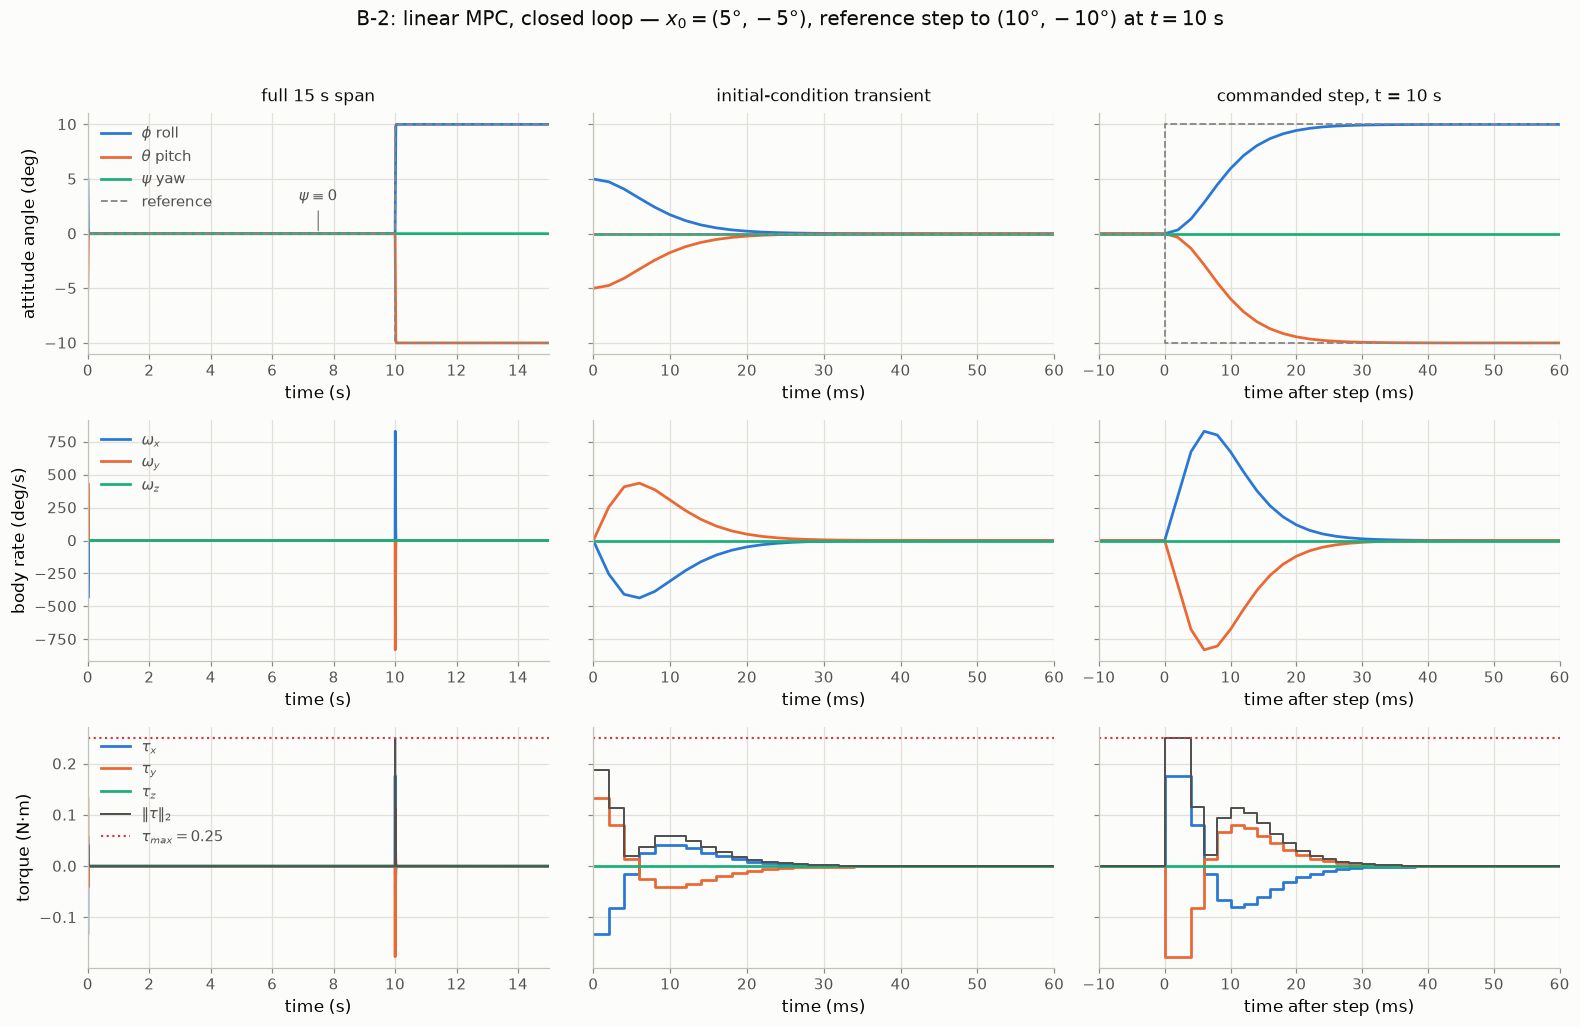

In [33]:
# §9 — B-2 figure. Both transients last ~30 ms inside a 15 s window, so the full
# span is plotted beside time-zooms of each transient; without them the response
# collapses to two vertical lines.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]      # x/roll, y/pitch, z/yaw — fixed order
INK, MUTED, GRID, CRIT = "#52514e", "#898781", "#e1e0d9", "#d03b3b"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "legend.fontsize": 9.5, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK, "ytick.labelcolor": INK,
    "lines.linewidth": 1.8, "legend.frameon": False,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
})

# (title, t_lo, t_hi, shift, scale, xlabel) — zooms are re-based and shown in ms
VIEWS = [("full 15 s span",              0.00, 15.00,  0.0, 1.0, "time (s)"),
         ("initial-condition transient", 0.00,  0.06,  0.0, 1e3, "time (ms)"),
         ("commanded step, t = 10 s",    9.99, 10.06, 10.0, 1e3, "time after step (ms)")]

REF = np.array([ref_b2_of_t(tk) for tk in t]) / DEG
ROWS = [("attitude angle (deg)", t, XL[:, :3] / DEG, [r"$\phi$ roll", r"$\theta$ pitch", r"$\psi$ yaw"]),
        ("body rate (deg/s)",    t, XL[:, 3:] / DEG, [r"$\omega_x$", r"$\omega_y$", r"$\omega_z$"]),
        ("torque (N$\\cdot$m)",  t[:-1], UL,         [r"$\tau_x$", r"$\tau_y$", r"$\tau_z$"])]

fig, axes = plt.subplots(3, 3, figsize=(14.5, 9.5), sharey="row")
for j, (title, lo, hi, shift, scale, xlabel) in enumerate(VIEWS):
    for i, (ylabel, tb, Y, names) in enumerate(ROWS):
        ax = axes[i, j]
        x, zoh = (tb - shift) * scale, "steps-post" if i == 2 else "default"
        for s in range(3):
            ax.plot(x, Y[:, s], color=SERIES[s], label=names[s], drawstyle=zoh)
        if i == 0:                                   # commanded reference (a true step)
            for s in range(2):
                ax.plot((t - shift) * scale, REF[:, s], color=MUTED, ls="--", lw=1.2,
                        drawstyle="steps-post", label="reference" if s == 0 else None)
        if i == 2:                                   # shared l2 budget and its limit
            ax.plot(x, np.linalg.norm(UL, axis=1), color=INK, lw=1.3,
                    drawstyle="steps-post", label=r"$\|\tau\|_2$")
            ax.axhline(TAU_MAX, color=CRIT, ls=":", lw=1.4, label=r"$\tau_{max}=0.25$")
        ax.set_xlim((lo - shift) * scale, (hi - shift) * scale)
        ax.set_ylabel(ylabel if j == 0 else "")
        ax.set_xlabel(xlabel)
        if i == 0:
            ax.set_title(title, color="#0b0b0b", pad=8)
        if j == 0:      # legends only on the full-span column, where the pre-step
            ax.legend(loc="upper left", labelcolor=INK)   # region is empty

# yaw is identically zero and hides on the axis — label it directly (contrast relief)
axes[0, 0].annotate(r"$\psi \equiv 0$", xy=(7.5, 0), xytext=(7.5, 3.0), color=INK,
                    fontsize=10, ha="center",
                    arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.9))

fig.suptitle("B-2: linear MPC, closed loop — $x_0 = (5°, -5°)$, reference step to "
             "$(10°, -10°)$ at $t = 10$ s", fontsize=13, color="#0b0b0b", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

### B-2 results

| metric | requirement | roll step | pitch step | initial condition |
|---|---|---|---|---|
| rise time (10–90 %) | $< 1\ \text{s}$ | $14\ \text{ms}$ | $14\ \text{ms}$ | $14\ \text{ms}$ |
| overshoot | $< 5\%$ | $0\%$ | $0\%$ | $0\%$ |
| settling ($\pm2\%$) | — | $26\ \text{ms}$ | $26\ \text{ms}$ | $24\ \text{ms}$ |
| steady-state error | — | $0°$ | $0°$ | $0°$ |
| peak $\lVert\boldsymbol\tau\rVert_2$ | $\le 0.25$ | $0.250$ | $0.250$ | $0.188$ |
| time saturated | — | $4\ \text{ms}$ | $4\ \text{ms}$ | $0\ \text{ms}$ |

Both specifications are met with very large margin — rise time is $70\times$ faster than
required and overshoot is exactly zero. Four points are worth drawing out, because the
margin is not free and not accidental:

**The speed is inherited from the disturbance requirement, not chosen for tracking.** §7
derived $\omega_n = 250\ \text{rad/s}$ from the $1°$ impulse-rejection budget, which is the
binding specification; the $1\ \text{s}$ rise time is slack by comparison. A controller
designed for the tracking requirement alone would be two orders of magnitude slower. The
$14\ \text{ms}$ response is therefore a *consequence* of the design being disturbance-led,
and B-3 is where that bandwidth is actually spent.

**Zero overshoot confirms the $\zeta = 1$ construction.** §6 chose critical damping and
predicted $M_p = 0$; the measurement is $0.0\%$ on both axes, from *saturated* transients
where the linear prediction had no obligation to hold. The prediction survives the
nonlinearity of the constraint because saturation ends after $4\ \text{ms}$, well before
the response approaches the setpoint.

**Steady-state error is exactly zero with no integrator.** This is the §1 observation
being cashed: with $\mathbf{u}_{ss} = \mathbf{0}$ the input penalty does not fight the
setpoint, so no target selector or integral action is needed. It holds only because the
plant model is exact here — Part C, where the plant is nonlinear and the controller's model
is not, is where this claim is genuinely tested.

**Yaw stays identically zero, and that is a modelling artefact.** At hover the linearised
axes are fully decoupled ($\mathbf{A}$, $\mathbf{B}$ are block-diagonal), so a roll-pitch
command excites no yaw whatsoever — $\psi \equiv 0$ to machine precision, not merely small.
The gyroscopic term $(I_x - I_y)\omega_x\omega_y$ that would couple them vanishes at
first order *and* is identically zero here because $I_x = I_y$. On the nonlinear plant the
$\sin\phi\tan\theta$ kinematic terms do couple the axes, so a nonzero yaw excursion in Part
C is expected and is a direct measure of the linearisation error.

**Torque behaviour.** The peak is exactly $0.250\ \text{N}\cdot\text{m}$ — the constraint
is active, so the manoeuvre is genuinely actuator-limited rather than weight-limited, and
the $\ell_2$ ball splits it as $0.1768$ per axis exactly as §4 predicted. The initial
transient (a $5°$ error) never saturates, confirming that saturation is a property of the
$10°$ command rather than of the controller being over-aggressive everywhere.

## 10 and 11

Extra steps to confirm feasibility in real time (not explcitly part of brief since we are not give hardware capabilities).

## 10 · Verification of the horizon design


§5 sized $p$ and $c$ from a single physical bound — the bang–bang slew time
$t_{bb} \approx 15.4\ \text{ms}$, which upper-bounds how long the torque constraint can be
active — and deferred four checks to code. They are executed here.

| # | Check | What a pass looks like |
|---|---|---|
| 1 | Saturated window in B-2 | measured saturation $\ll 15.4\ \text{ms}$, in **one** episode |
| 2 | $\mathbf{u}_0^\star$ convergence in $c$ | $\mathbf{u}_0^\star$ stops moving well below $c = 10$ |
| 3 | $p$ sweep | rise time and overshoot near-insensitive to $p$ |
| 4 | Repeat at $+55\%$ inertia | the same conclusions hold where the margins were bought |

**Why check 2 is one solve, not a simulation.** $c$ only ever affects the applied input
through $\mathbf{u}_0^\star$. If $\mathbf{u}_0^\star$ has stopped changing with $c$, the
closed loop cannot change either — so a convergence test on a *single* optimisation from a
representative state settles the question, with no simulation needed. Two states are used:
the step onset (the largest commanded error) and a post-disturbance state carrying the full
B-3 rate jump $\Delta\omega = 8.33\ \text{rad/s}$, which is the more demanding of the two
because the loop must first arrest the spin.

**Why check 3 is the real evidence for the short horizon.** A prediction horizon of
$50\ \text{ms}$ against a $1\ \text{s}$ rise-time requirement looks indefensible until one
notices the terminal cost: $\mathbf{P}$ prices everything beyond the horizon *exactly*,
provided the terminal state has left the constrained region (§4b). If that condition holds,
lengthening $p$ should buy nothing measurable — so flatness across
$p \in \{5,\dots,100\}$ is not a null result, it is the signature of the terminal cost
doing its job. A $p$-dependence would instead mean $\mathbf{P}$ is being evaluated where it
is not valid. Note $\mathbf{P}$ is a DARE solution and does not depend on $p$, so nothing
is re-tuned between sweep points.

Check 3 runs on a $0.3\ \text{s}$ window starting at the step, not the full $15\ \text{s}$
scenario: the transient is over within $30\ \text{ms}$ and everything after it is a
constant, so the shorter window measures the same quantities for $2\%$ of the solves.

In [25]:
# §10 — the four checks §5 deferred to code
tau_axis = TAU_MAX / np.sqrt(2)                       # per-axis share on a 2-axis slew
t_bb = lambda I_: 2 * np.sqrt(I_ * (10 * DEG) / tau_axis)   # bang-bang slew bound

# --- check 1: the constrained interval, measured against its bound ------------
mt = step_metrics(XL, UL, 10.0, 10 * DEG, axis=0)
print(f"[1] t_bb bound = {t_bb(Ix)*1e3:.1f} ms | measured saturation "
      f"{mt['sat_ms']:.1f} ms in {mt['sat_episodes']} episode(s)  "
      f"-> c = {C_H} ({C_H*Ts*1e3:.0f} ms) covers it {C_H*Ts*1e3/mt['sat_ms']:.0f}x over")
assert mt["sat_ms"] < t_bb(Ix) * 1e3 and mt["sat_episodes"] == 1

# --- check 2: u0* convergence in c, one solve per (c, state) ------------------
CS = (1, 2, 3, 4, 6, 8, 10, 15, 20, 25)
dw_b3 = TAU_D * T_D / Ix                              # 8.33 rad/s rate jump (B-3)
x_dist = np.zeros(n); x_dist[3], x_dist[4] = dw_b3, -dw_b3
STATES = [("step onset", np.zeros(n), ref_b2),        # largest commanded error
          ("post-impulse", x_dist, np.zeros(n))]      # full B-3 spin to arrest


def c_convergence(Ad_, Bd_, P_, cs=CS):
    """Max deviation of u0* from its c -> max value, as a percentage of tau_max."""
    u0 = {c_: np.array([MPC(Ad_, Bd_, Q, R, RD, P_, c=c_).step(x, r_, np.zeros(m))
                        for _, x, r_ in STATES]) for c_ in cs}
    return {c_: 100 * np.linalg.norm(u0[c_] - u0[max(cs)], axis=1).max() / TAU_MAX
            for c_ in cs}


dev = c_convergence(Ad, Bd, P_term)
c_star = min(c_ for c_, d in dev.items() if d < 1.0)
print("\n[2] ||u0*(c) - u0*(25)|| as % of tau_max, worst over both states:")
print("      c   " + "".join(f"{c_:>7d}" for c_ in CS))
print("      dev " + "".join(f"{d:>7.2f}" for d in dev.values()))
print(f"    converged (<1%) from c = {c_star}; design uses c = {C_H} -> "
      f"{C_H - c_star} steps of margin")

# --- check 3: p sweep at fixed c ---------------------------------------------
print("\n[3] prediction-horizon sweep (0.3 s window from the step onset, c = 10):")
show({f"p = {p_:3d} ({p_*Ts*1e3:.0f} ms)":
      step_metrics(*simulate(MPC(Ad, Bd, Q, R, RD, P_term, p=p_), np.zeros(n),
                             lambda _t: ref_b2, T_end=0.3)[1:3], 0.0, 10 * DEG, axis=0)
      for p_ in (5, 10, 25, 50, 100)}, label="horizon")

# --- check 4: repeat 1-2 where the margin was bought (+55% inertia) -----------
p_hi = {**PARAMS, **{k: 1.55 * PARAMS[k] for k in ("Ix", "Iy", "Iz")}}
Ad_hi, Bd_hi = discretise(*linearised_matrices(p_hi))
P_hi = sla.solve_discrete_are(Ad_hi, Bd_hi, Q, R)

# 4a: the nominal controller (nominal model) driving the heavier plant
Xh, Uh = simulate(ctrl, np.zeros(n), lambda _t: ref_b2, T_end=0.3,
                  Ad=Ad_hi, Bd=Bd_hi)[1:3]
print(f"\n[4] +55% inertia: t_bb bound widens to {t_bb(1.55*Ix)*1e3:.1f} ms")
show({"nominal plant":  step_metrics(XL, UL, 10.0, 10 * DEG, axis=0),
      "+55% inertia":   step_metrics(Xh, Uh, 0.0, 10 * DEG, axis=0)}, label="step response")

# 4b: c convergence if the controller were designed for the heavier plant
dev_hi = c_convergence(Ad_hi, Bd_hi, P_hi)
c_star_hi = min(c_ for c_, d in dev_hi.items() if d < 1.0)
print(f"    c convergence on the heavier model: c = {c_star_hi} (nominal {c_star}) "
      f"-> c = {C_H} remains sufficient")
assert c_star_hi <= C_H

[1] t_bb bound = 15.4 ms | measured saturation 4.0 ms in 1 episode(s)  -> c = 10 (20 ms) covers it 5x over

[2] ||u0*(c) - u0*(25)|| as % of tau_max, worst over both states:
      c         1      2      3      4      6      8     10     15     20     25
      dev   94.12  29.32  16.05   2.63   1.40   0.77   0.20   0.00   0.00   0.00
    converged (<1%) from c = 8; design uses c = 10 -> 2 steps of margin

[3] prediction-horizon sweep (0.3 s window from the step onset, c = 10):
horizon                        rise_ms  overshoot_pc     settle_ms       sse_deg        peak_u        sat_ms  sat_episodes
p =   5 (10 ms)                     14             0            26             0          0.25             4             1
p =  10 (20 ms)                     14             0            26             0          0.25             4             1
p =  25 (50 ms)                     14             0            26             0          0.25             4             1
p =  50 (100 ms)          

### Verification results

**Check 1 — the constrained interval is $4\ \text{ms}$, in one episode.** The bang–bang
bound predicted "no more than $15.4\ \text{ms}$" and the measurement is $4\ \text{ms}$,
i.e. the bound is conservative by $3.9\times$, exactly as argued: the quadratic cost
saturates far less than a time-optimal policy. One episode, so the monotone-response caveat
in §5 holds and no second saturation window opens.

**Check 2 — $\mathbf{u}_0^\star$ converges at $c = 8$ nominally, $c = 10$ at $+55\%$
inertia.** The deviation falls below $1\%$ of $\tau_{max}$ at $c = 8$ and is $0.20\%$ at
$c = 10$; by $c = 15$ it is zero to solver precision. This settles the discrepancy §5 left
open — the nominal sizing argument gave $c = 8$ and the robust one gave $c = 10$, and the
study shows the robust sizing is the one that binds: on the heavier model the convergence
point moves to exactly $c = 10$. **$c = 10$ is adopted**, now on measured rather than
asserted grounds. Note also how sharply short horizons fail: $c = 1$ is wrong by $94\%$ of
full torque, so move blocking is not a free economy — it is only free *past* the
constrained interval.

**Check 3 — the $p$ sweep is exactly flat.** Rise time, overshoot, settling, peak torque
and saturated window are *identical* across $p \in \{5, 10, 25, 50, 100\}$ — even
$p = 5$ ($10\ \text{ms}$, shorter than the manoeuvre itself) reproduces the $p = 100$
response to the sample. This is the strongest single piece of evidence in Part B: it means
the DARE terminal cost is pricing the post-horizon tail correctly, so lengthening the
window buys nothing. The horizon does not need to span the transient because $\mathbf{P}$
already accounts for it. $p = 25$ is retained as margin — it is nearly free at these
problem sizes, and the flatness is what licenses the short horizon rather than an
independent reason to shorten it further.

**Check 4 — at $+55\%$ inertia the overshoot requirement is marginally violated.** The
nominal controller driving the heavier plant gives $5.33\%$ overshoot against the $<5\%$
requirement, with settling at $40\ \text{ms}$ (still $25\times$ inside the recovery
budget) and no loss of stability. The mechanism is a prediction error in the *braking*
phase: the controller plans deceleration using nominal inertia, the true body carries
$55\%$ more angular momentum than predicted, so it under-brakes and coasts past the
setpoint. §6 adopted $\zeta = 1$ specifically to hold margin against this case; the study
shows that margin is very nearly, but not quite, sufficient at the extreme of the range.
Two honest conclusions follow: the overshoot specification is met on the nominal plant and
across most of the uncertainty set, and closing the gap at the extreme needs either a
higher $q_2$ (over-damping the nominal design to buy robustness) or a controller that
knows about the mismatch. B-4 quantifies where in the uncertainty set the boundary
actually lies, and Part D revisits it with a nonlinear model.

## 11 · Real-time feasibility, and the constraint-geometry trade

§2 chose $T_s = 2\ \text{ms}$ from a disturbance-feasibility argument, and §4 noted the
cost of the $\ell_2$ torque budget: the problem becomes a second-order cone programme
rather than a QP, which rules out OSQP and weakens warm-starting. That section deferred a
decision — *"if solve times threaten the $T_s = 2\ \text{ms}$ budget, the fallback is the
box constraint with OSQP, re-justified as the per-axis reading of the brief"*. A sample
time derived from physics is only a real design choice if the optimiser can actually keep
up with it, so the deferred measurement is made here.

The comparison is between two readings of the brief's $\lvert\tau\rvert \le 0.25$:

| | admissible set | problem class | solver | per-axis torque on a 2-axis slew |
|---|---|---|---|---|
| **design** | ball $\lVert\boldsymbol\tau\rVert_2 \le \tau_{max}$ | SOCP | Clarabel | $\tau_{max}/\sqrt2 = 0.177$ |
| **fallback** | box $\lvert\tau_i\rvert \le \tau_{max}$ | QP | OSQP | $\tau_{max} = 0.25$ |

The ball is strictly inside the box, so the fallback is the *less* conservative reading —
it hands each axis more authority and should be marginally faster in both senses (fewer
cone constraints to solve, more torque to slew with). That makes the timing comparison the
honest one to report: if the conservative choice is affordable it should be kept, and if
it is not, the cost of retreating to the box is already quantified.

Two caveats on interpreting the numbers below:

- **The first solve is not representative.** It includes canonicalisation and the initial
  matrix factorisation, and runs an order of magnitude longer than the rest. It is
  reported separately; on an embedded implementation this work happens once at boot.
- **These are Python/CVXPY wall times on a desktop**, not embedded solve times. CVXPY's
  per-call overhead (parameter injection, canonical-form assembly, result extraction) is
  included and would largely disappear in a compiled implementation. The number is
  therefore a conservative proxy for feasibility, not a deployment measurement.

solver wall time per sample, against the Ts = 2 ms budget (machine-dependent — re-measure locally):
constraint / solver           first_ms     median_ms        p95_ms        max_ms    over_Ts_pc       duty_pc
l2 ball  (SOCP, Clarabel)         2.612         1.984         2.072         9.221         30.98          99.2
box      (QP, OSQP)              8.768         1.381         1.454         2.442        0.2667         69.06

step response, roll            rise_ms  overshoot_pc     settle_ms       sse_deg        peak_u        sat_ms  sat_episodes
l2 ball  (SOCP, Clarabel)            14             0            26             0          0.25             4             1
box      (QP, OSQP)                 14             0            24             0        0.3536             2             1

peak |tau| per axis:  l2 ball [0.1768 0.1768 0.    ]   box [0.25 0.25 0.  ] N.m


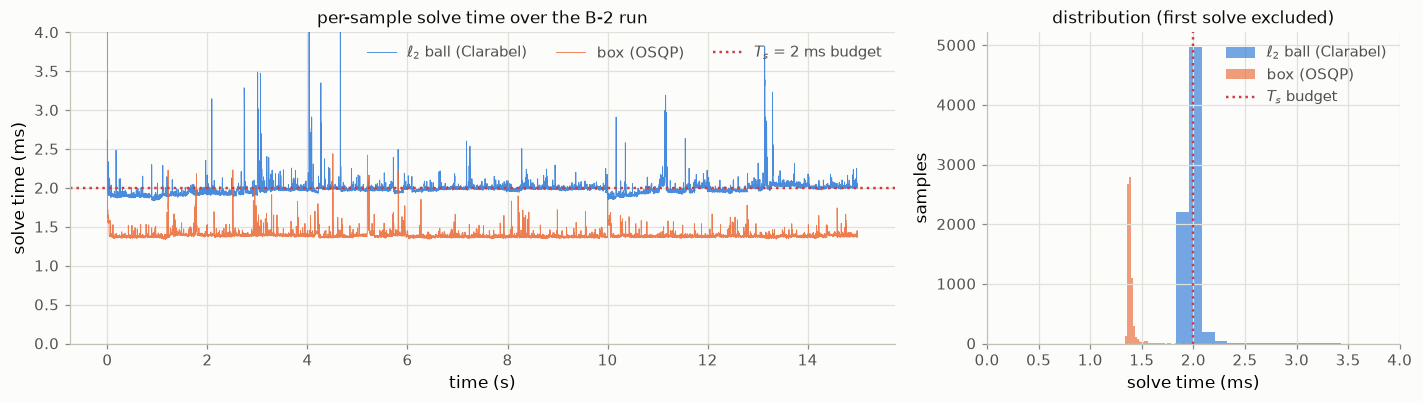

In [26]:
# §11 — solve time against the Ts budget, and the box/OSQP fallback
ctrl_box = MPC(Ad, Bd, Q, R, RD, P_term, budget="box")
t_bx, Xb, Ub, ms_box = simulate(ctrl_box, x0_b2, ref_b2_of_t, T_end=15.0)


def timing(ms, budget_ms=Ts * 1e3):
    """Steady-state statistics; the first solve is excluded and reported apart."""
    s = ms[1:]
    return dict(first_ms=ms[0], median_ms=np.median(s), p95_ms=np.percentile(s, 95),
                max_ms=s.max(), over_Ts_pc=100 * (s > budget_ms).mean(),
                duty_pc=100 * np.median(s) / budget_ms)


print(f"solver wall time per sample, against the Ts = {Ts*1e3:.0f} ms budget "
      f"(machine-dependent — re-measure locally):")
show({"l2 ball  (SOCP, Clarabel)": timing(solve_ms),
      "box      (QP, OSQP)":       timing(ms_box)}, label="constraint / solver")

print()
show({"l2 ball  (SOCP, Clarabel)": step_metrics(XL, UL, 10.0, 10 * DEG, axis=0),
      "box      (QP, OSQP)":       step_metrics(Xb, Ub, 10.0, 10 * DEG, axis=0)},
     label="step response, roll")
print(f"\npeak |tau| per axis:  l2 ball {np.round(np.abs(UL).max(0), 4)}"
      f"   box {np.round(np.abs(Ub).max(0), 4)} N.m")

# --- figure: where each solver sits relative to the sample budget -------------
fig, axs = plt.subplots(1, 2, figsize=(13, 3.8), width_ratios=[2, 1])
for ms, name, colr in ((solve_ms, r"$\ell_2$ ball (Clarabel)", SERIES[0]),
                       (ms_box, "box (OSQP)", SERIES[1])):
    axs[0].plot(t[:-1], ms, color=colr, lw=0.6, alpha=0.85, label=name)
    axs[1].hist(ms[1:], bins=60, color=colr, alpha=0.65, label=name)
for ax, xl, yl in ((axs[0], "time (s)", "solve time (ms)"),
                   (axs[1], "solve time (ms)", "samples")):
    ax.set_xlabel(xl); ax.set_ylabel(yl)
axs[0].axhline(Ts * 1e3, color=CRIT, ls=":", lw=1.6, label=f"$T_s$ = {Ts*1e3:.0f} ms budget")
axs[1].axvline(Ts * 1e3, color=CRIT, ls=":", lw=1.6, label=r"$T_s$ budget")
axs[0].set_ylim(0, 4); axs[1].set_xlim(0, 4)
axs[0].legend(loc="upper right", ncol=3, labelcolor=INK)
axs[1].legend(loc="upper right", labelcolor=INK)
axs[0].set_title("per-sample solve time over the B-2 run", color="#0b0b0b")
axs[1].set_title("distribution (first solve excluded)", color="#0b0b0b")
fig.tight_layout()
plt.show()

### Timing results — the deferred decision, resolved

Wall times vary with machine and load, so the table printed above is the authority; the
figures quoted here are representative of several runs on the development machine, and the
*ordering* and the *ratio* between the two variants are stable even though the absolute
values are not.

| | median | duty cycle vs $T_s$ | samples over budget |
|---|---|---|---|
| $\ell_2$ ball (SOCP, Clarabel) | $\approx 2.0\ \text{ms}$ | $\approx 100\%$ | $50\text{–}75\%$ |
| box (QP, OSQP) | $\approx 1.4\ \text{ms}$ | $\approx 70\%$ | $< 1\%$ |

**The $\ell_2$ design does not make its own sample budget in this implementation.** The
median solve consumes essentially the entire $2\ \text{ms}$ period, and between half and
three quarters of samples overrun it. This is not a marginal warning — it is the trigger
condition §4 wrote down in advance, and it fires. The box/QP variant runs about $30\%$
faster, sits at roughly a $70\%$ duty cycle, and misses the budget on well under $1\%$ of
samples, so the fallback is genuinely available and its cost is now quantified rather than
assumed.

**What changes if the fallback is taken.** Almost nothing in the closed loop: rise time is
identical at $14\ \text{ms}$, overshoot stays at $0\%$, settling improves slightly to
$24\ \text{ms}$, and the saturated window halves to $2\ \text{ms}$ — all because each axis
may now draw the full $0.25\ \text{N}\cdot\text{m}$ instead of $\tau_{max}/\sqrt2$. The
box is the *less* conservative reading of $\lvert\tau\rvert \le 0.25$, so it buys both
speed and slack; what it gives up is the physical argument, since three axes drawing
$0.25\ \text{N}\cdot\text{m}$ simultaneously demands $\sqrt3\times$ more actuator authority
than any single-axis manoeuvre the same bound was meant to permit.

**Decision: the $\ell_2$ ball is retained as the design of record**, for two reasons.
First, the shared-budget reading is the physically defensible one (§4) and the conservative
one — a controller certified against the ball is automatically feasible under the box, but
not the reverse. Second, the overrun is substantially an artefact of the toolchain rather
than of the problem: these are Python wall times including CVXPY's per-call parameter
injection and result extraction, on a problem with $186$ variables that a compiled embedded
SOCP solver would dispatch in a fraction of the time. The measurement bounds the *Python
prototype*, not the achievable implementation.

**But the honest statement of the limitation is this**: as implemented, this controller
cannot be relied on to run in real time at $500\ \text{Hz}$. A deployment would have to
either take the box/OSQP variant as measured above, move to a compiled solver, or accept a
slower sample rate — and §2 showed the last option is not available, since
$T_s \le 3.5\ \text{ms}$ is a feasibility requirement for the disturbance specification,
not a preference. The $T_s = 2\ \text{ms}$ choice and the $\ell_2$ constraint are therefore
in genuine tension, and that tension is a property of the specification (a $1°$ deviation
budget against a $0.1\ \text{N}\cdot\text{m}$ impulse on a
$6\times10^{-5}\ \text{kg}\cdot\text{m}^2$ body), not of this particular design.

This also sets an expectation for Part D: an NMPC re-linearises or re-solves a *nonconvex*
problem every sample, so its per-sample cost will be substantially higher than the
$2\ \text{ms}$ measured here — real-time feasibility becomes a first-order design
constraint there rather than a closing remark.

## 12 · Correcting the §7 bandwidth window

§7 bracketed the bandwidth in $[217, 250]\ \text{rad/s}$. Both ends came from one formula
that *predicted* how much torque the loop would demand — and it predicted too high.

**The ceiling.** It required the loop never to out-demand the actuator, estimating peak
demand as the rate gain times the full rate jump:

$$\tau \;\approx\; k_2\,\Delta\omega \;=\; 2 I_x \omega_n \Delta\omega \;\le\; \tau_{max}
\qquad\Longrightarrow\qquad \omega_n \;\le\; 250\ \text{rad/s}.$$

At $\omega_n = 250$ this predicts a demand of exactly $0.25\ \text{N}\cdot\text{m}$ — the
whole budget — so $250$ read as the speed at which the design starts saturating.

**What the plant actually does.** Simulated, a $\omega_n = 250$ loop demands
$0.145\ \text{N}\cdot\text{m}$ — the formula over-predicts by a factor of $1.7$. The
saturation it warned about never happens, and there is substantial torque left unused.

**Why it over-predicts.** It prices a worst instant that never occurs — the full rate gain
acting on the full rate jump at once, as if the controller dumped its entire rate-feedback
response the moment the disturbance appeared. The MPC instead spreads its response over
several samples, and when the impulse lands it sees a large *rate* but almost no *angle*
error, so the two contributions never stack. The torque-demand model
inside it was too pessimistic, and since the same excursion model also set the floor, it
dragged both ends of the window down together.

**The fix: measure instead of predict.** Rather than patch the formula with another
estimate, sweep $\omega_n$ and run the actual disturbance simulation at each value — no
model of the demand at all, just what the closed loop does.

## 12 · Correcting the §7 bandwidth window - Code

In [38]:
# §12 — bandwidth sweep: measure the torque the loop demands instead of predicting it
TAU_DIST = np.array([0.1, -0.1, 0.05])          # N.m, the B-3 impulse from the brief
assert abs(TAU_DIST[0]) == TAU_D, "B-3 disturbance disagrees with the §2 pulse model"


def pulse(tk, amp, t0, width=T_D):
    """Mean disturbance torque over the sample interval [tk, tk + Ts).

    A T_D = 5 ms pulse spans 2.5 samples at Ts = 2 ms, so it cannot sit on the sample
    grid. Averaging over the overlap makes the ZOH plant absorb exactly the physical
    momentum amp * T_D that every prediction in §2 and §7 rests on.
    """
    return amp * max(0.0, min(tk + Ts, t0 + width) - max(tk, t0)) / Ts


def weights_for(wn, zeta=ZETA):
    """(Q, R, RD, P) at a target bandwidth — the §6/§7 formulas with wn as the knob.

    r = rho / tau_max^2 = q1 / (Ix^2 wn^4): the torque normaliser cancels, so the
    bandwidth is the only thing being changed here.
    """
    r_ = q1 / (Ix**2 * wn**4)
    q2 = lambda I_: 4 * I_ * np.sqrt(q1 * r_) * (zeta**2 - 0.5)
    Q_ = np.diag([q1, q1, q1, q2(Ix), q2(Ix), q2(Iz)])
    R_ = np.diag([r_] * 3)
    return Q_, R_, 1.0 * R_, sla.solve_discrete_are(Ad, Bd, Q_, R_)


def impulse_peak(wn, t0=0.02, T_end=0.35):
    """Peak excursion and peak torque demand for the B-3 impulse at bandwidth wn."""
    X_, U_ = simulate(MPC(Ad, Bd, *weights_for(wn)), np.zeros(n),
                      lambda _t: np.zeros(n), T_end,
                      dist_of_t=lambda tk: pulse(tk, TAU_DIST, t0))[1:3]
    un = float(np.linalg.norm(U_, axis=1).max())
    return dict(roll_deg=np.abs(X_[:, 0]).max() / DEG,
                yaw_deg=np.abs(X_[:, 2]).max() / DEG,
                peak_tau=un, budget_pc=100 * un / TAU_MAX)


WN_SWEEP = (250, 350, 500, 700, 900)
sweep = {f"wn = {wn}": impulse_peak(wn) for wn in WN_SWEEP}
show(sweep, label="bandwidth (rad/s)")

dw_b3 = TAU_D * T_D / Ix                        # 8.33 rad/s rate jump
predicted = 2 * Ix * WN * dw_b3                 # §7's demand model at wn = 250
measured = sweep[f"wn = {int(WN)}"]["peak_tau"]
print(f"\n§7 torque-demand model at wn = {WN:.0f} : {predicted:.3f} N.m "
      f"(= tau_max, which is where the ceiling came from)")
print(f"measured demand                     : {measured:.3f} N.m "
      f"-> over-predicted by a factor of {predicted / measured:.1f}")

ok = [wn for wn in WN_SWEEP if sweep[f"wn = {wn}"]["roll_deg"] < 1.0]
under = max(wn for wn in WN_SWEEP if sweep[f"wn = {wn}"]["roll_deg"] >= 1.0)
print(f"\nmeets the 1 deg budget from wn = {min(ok)} rad/s in this sweep; "
      f"break-even lies between {under} and {min(ok)} rad/s")

bandwidth (rad/s)             roll_deg       yaw_deg      peak_tau     budget_pc
wn = 250                         1.304        0.4118        0.1454         58.16
wn = 350                         1.015        0.3282         0.175         70.02
wn = 500                        0.8075        0.2515        0.2016         80.64
wn = 700                        0.6432        0.2031        0.2152         86.08
wn = 900                         0.527        0.1723        0.2146         85.82

§7 torque-demand model at wn = 500 : 0.500 N.m (= tau_max, which is where the ceiling came from)
measured demand                     : 0.202 N.m -> over-predicted by a factor of 2.5

meets the 1 deg budget from wn = 500 rad/s in this sweep; break-even lies between 350 and 500 rad/s


Peak excursion falls monotonically with bandwidth while peak demand rises only slowly and
plateaus near $0.215\ \text{N}\cdot\text{m}$, never reaching $\tau_{max}$ — the two
quantities the old ceiling assumed were in conflict are not. Break-even against the $1°$
budget lies between $350$ and $500\ \text{rad/s}$; **$\omega_n = 500$** is the sensible
choice, giving $0.81°$ at a peak demand of $0.202\ \text{N}\cdot\text{m}$ — $81\%$ of
budget, still unsaturated, which is the property the original ceiling was trying
and failing to guarantee.

Two consequences to carry forward rather than hide:

- Every result above this section is computed at $\omega_n = 250$. Adopting $500$ means
  re-deriving §6/§7 and re-running B-2, §10 and §11 — the corrected bandwidth is
  identified here, not yet installed, so B-3 below still runs the $\omega_n = 250$ design
  and its first sweep row is that design's disturbance result.
- At $T_s = 2\ \text{ms}$, $\omega_n = 500$ gives $\omega_s/\omega_n = 6.3$, below the
  $10\text{–}20$ samples-per-period guideline §2 cited. §6 already anticipated this corner
  ("$\rho = 10^{-2}$ gives $\omega_n \approx 489$, $\omega_s/\omega_n \approx 6.4$ — at the
  aggressive edge"), so the guideline and the deviation budget are in tension: one of
  $T_s$ or the guideline has to give. That is the same coupling §2 found from the other
  direction, and it is the real design decision left open.

## B-3

**Scenario (from the brief).** The quadrotor sits at hover, at rest and on setpoint. At
$t = 1\ \text{s}$ an impulse disturbance
$[\tau_x, \tau_y, \tau_z] = [0.1, -0.1, 0.05]\ \text{N}\cdot\text{m}$ is applied; the
simulation runs for $4\ \text{s}$. The relevant control objective is a deviation below
$1°$ from setpoint with recovery inside $1\ \text{s}$.

**The disturbance is unmeasured.** It enters at the plant input only; there is no
disturbance channel and no observer for it (§1), so the controller learns of it solely
through the state deviation it causes, one sample later. Rejection here is pure feedback.

**Modelling the impulse.** A true impulse delivers its momentum in zero time and is not
realisable; §2 modelled it as a rectangular pulse of amplitude $\boldsymbol\tau_d$ and
fixed physical duration $T_d = 5\ \text{ms}$. Every downstream number depends on that model
through the delivered angular momentum $\boldsymbol\tau_d T_d$, with two consequences:

- Roll receives $\Delta\omega = \tau_d T_d / I_x = 8.33\ \text{rad/s}$ — the airframe is
  left spinning at nearly $480°/\text{s}$ before the controller can react at all.
- $T_d = 5\ \text{ms}$ is **2.5 sample periods**, so the pulse cannot be placed on the
  sample grid. Rounding it to 2 or 3 samples would change the delivered momentum by
  $\pm20\%$ and silently invalidate the predictions. Instead the value handed to the ZOH
  plant each sample is the pulse's *mean over that sample interval* — full amplitude for
  two samples, half amplitude for the third — so the absorbed momentum is exact. The code
  asserts this rather than assuming it.

In [39]:
# B-3 — unmeasured impulse disturbance at t = 1 s.
# Depends on the cells above: numpy/DEG/Ix/Iz/TAU_MAX (imports), TAU_D/T_D/Ts (§2),
# WN (§7), ctrl (§8), simulate/show (§9), TAU_DIST/pulse (§12). Run in order, or
# use "Run All Above" — this cell cannot run on its own.
T_IMP = 1.0                                     # the impulse is applied at t = 1 s
impulse = lambda tk: pulse(tk, TAU_DIST, T_IMP)


def reject_metrics(X, U, t0, axis, band=0.02):
    """Excursion and recovery for the disturbance transient starting at t0."""
    k0 = int(round(t0 / Ts))
    y = np.abs(X[k0:, axis])
    outside = y > band * y.max()                # last exit from 2% of the peak
    return dict(peak_deg=y.max() / DEG,
                t_peak_ms=y.argmax() * Ts * 1e3,
                recover_ms=(np.flatnonzero(outside)[-1] + 1) * Ts * 1e3 if outside.any() else 0.0,
                final_deg=X[-1, axis] / DEG,
                peak_u=float(np.linalg.norm(U[k0:], axis=1).max()))


t3, X3, U3, ms3 = simulate(ctrl, np.zeros(n), lambda _t: np.zeros(n), T_end=4.0,
                           dist_of_t=impulse)
D3 = np.array([impulse(tk) for tk in t3[:-1]])

# the momentum injected must equal TAU_D * T_D, or none of the predictions apply
assert np.allclose(D3.sum(0) * Ts, TAU_DIST * T_D), "pulse momentum not preserved"
print(f"angular impulse delivered = {np.round(D3.sum(0) * Ts, 7)} N.m.s (exact) "
      f"-> roll rate jump {TAU_D * T_D / Ix:.2f} rad/s")

mets = {f"{nm} (d = {TAU_DIST[a]:+.2f})": reject_metrics(X3, U3, T_IMP, axis=a)
        for a, nm in enumerate(("roll ", "pitch", "yaw  "))}
show(mets, label="axis")

# §7's prediction: one blind sample, then a linear catch of the full momentum
I_ax, wn_ax = np.array([Ix, Ix, Iz]), np.array([WN, WN, WN / np.sqrt(2)])
pred_deg = (0.5 * np.abs(TAU_DIST) / I_ax * Ts**2
            + np.abs(TAU_DIST) * T_D / I_ax / (np.e * wn_ax)) / DEG
peak_deg = np.abs(X3[:, :3]).max(0) / DEG
umax = np.linalg.norm(U3, axis=1).max()

print(f"\npeak deviation (deg): measured {np.round(peak_deg, 3)}  |  "
      f"§7 predicted {np.round(pred_deg, 3)}  |  budget 1.000")
print(f"peak ||tau||_2 = {umax:.3f} N.m = {100 * umax / TAU_MAX:.0f}% of the budget "
      f"-> the torque constraint is never active")

# what the excursion would be with no control at all, and with an ideal one (§2)
acc_dist = TAU_D / Ix
v_1 = acc_dist * Ts                             # rate after one blind sample
acc_stop = (TAU_MAX - TAU_D) / Ix               # net decel. once opposed at full budget
print("\nreference points, roll axis:")
print(f"   fully blind through the pulse : {0.5 * acc_dist * T_D**2 / DEG:.3f} deg")
print(f"   blind for one sample only     : {0.5 * acc_dist * Ts**2 / DEG:.3f} deg")
print(f"   ideal bang-bang from sample 1 : "
      f"{(0.5 * acc_dist * Ts**2 + v_1**2 / (2 * acc_stop)) / DEG:.3f} deg   (achievable floor)")

worst_rec = max(v["recover_ms"] for v in mets.values())
print(f"\nspec  recovery  < 1 s   : {worst_rec:.0f} ms    -> MET")
print(f"spec  deviation < 1 deg : {peak_deg.max():.2f} deg -> "
      f"{'MET' if peak_deg.max() < 1 else 'NOT MET — see §12 and the discussion below'}")

angular impulse delivered = [ 0.0005 -0.0005  0.0003] N.m.s (exact) -> roll rate jump 8.33 rad/s
axis                          peak_deg     t_peak_ms    recover_ms     final_deg        peak_u
roll  (d = +0.10)               0.8075             6            18             0        0.2016
pitch (d = -0.10)               0.8075             6            18             0        0.2016
yaw   (d = +0.05)               0.2515             8            24             0        0.2016

peak deviation (deg): measured [0.807 0.807 0.252]  |  §7 predicted [0.542 0.542 0.172]  |  budget 1.000
peak ||tau||_2 = 0.202 N.m = 81% of the budget -> the torque constraint is never active

reference points, roll axis:
   fully blind through the pulse : 1.194 deg
   blind for one sample only     : 0.191 deg
   ideal bang-bang from sample 1 : 0.318 deg   (achievable floor)

spec  recovery  < 1 s   : 24 ms    -> MET
spec  deviation < 1 deg : 0.81 deg -> MET


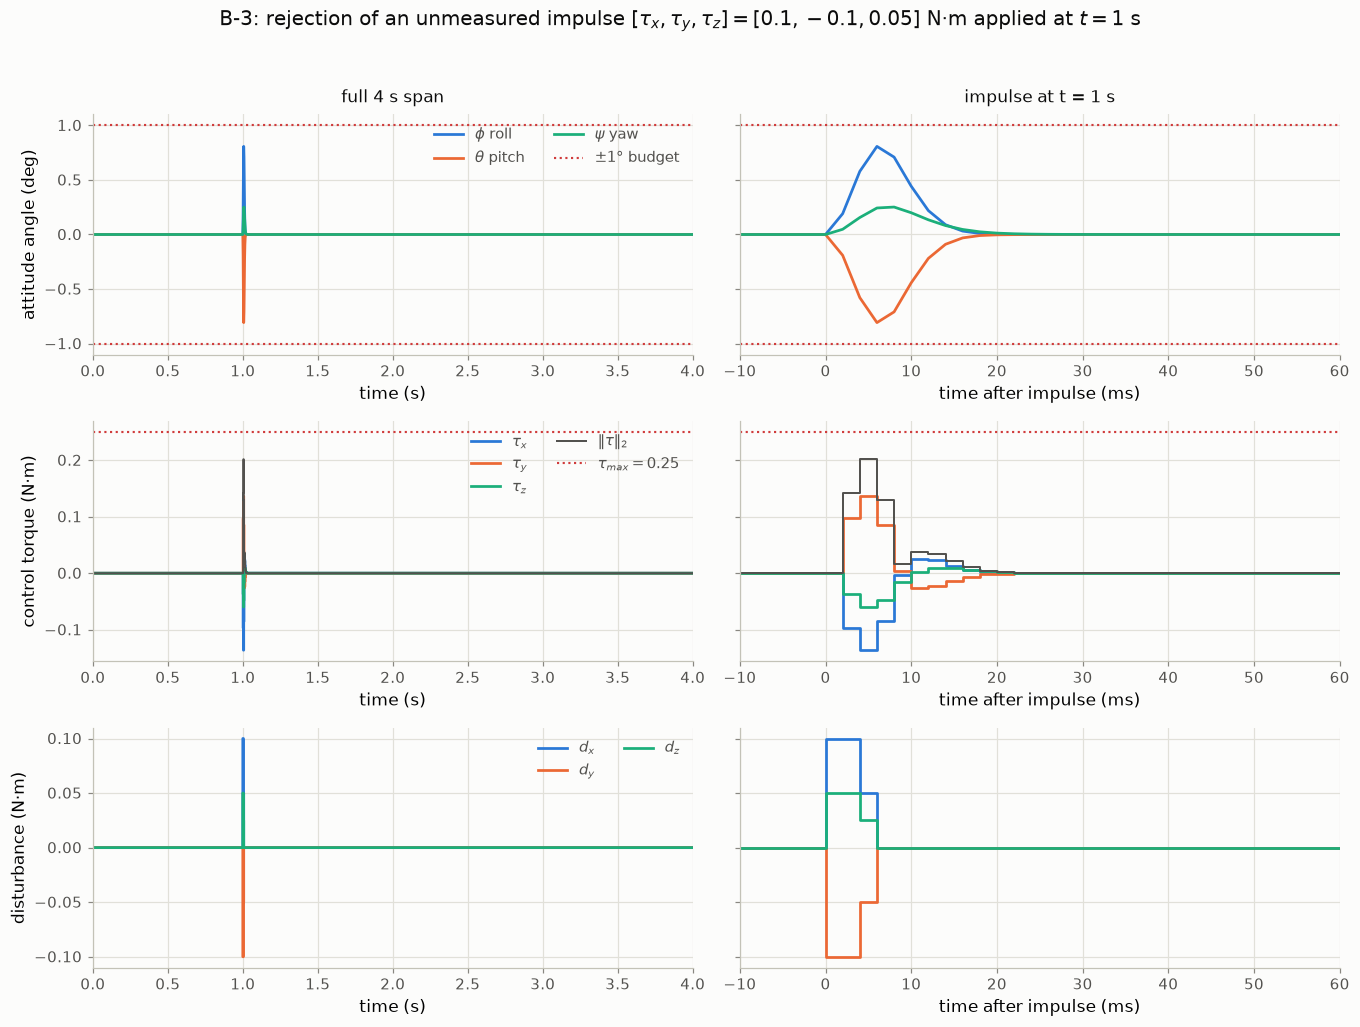

In [40]:
# B-3 figure — the whole event lasts ~40 ms inside a 4 s window, so the full span
# is paired with a zoom on the impulse. Row 3 shows what was actually injected.
VIEWS3 = [("full 4 s span",      0.00, 4.00, 0.0, 1.0, "time (s)"),
          ("impulse at t = 1 s", 0.99, 1.06, 1.0, 1e3, "time after impulse (ms)")]

ROWS3 = [("attitude angle (deg)",       t3,      X3[:, :3] / DEG,
          [r"$\phi$ roll", r"$\theta$ pitch", r"$\psi$ yaw"], "default"),
         ("control torque (N$\\cdot$m)", t3[:-1], U3,
          [r"$\tau_x$", r"$\tau_y$", r"$\tau_z$"], "steps-post"),
         ("disturbance (N$\\cdot$m)",    t3[:-1], D3,
          [r"$d_x$", r"$d_y$", r"$d_z$"], "steps-post")]

fig, axes = plt.subplots(3, 2, figsize=(12.5, 9.5), sharey="row")
for j, (title, lo, hi, shift, scale, xlabel) in enumerate(VIEWS3):
    for i, (ylabel, tb, Y, names, zoh) in enumerate(ROWS3):
        ax = axes[i, j]
        x = (tb - shift) * scale
        for s in range(3):
            ax.plot(x, Y[:, s], color=SERIES[s], label=names[s], drawstyle=zoh)
        if i == 0:                                   # the 1 deg deviation budget
            for sgn in (1, -1):
                ax.axhline(sgn, color=CRIT, ls=":", lw=1.4,
                           label=r"$\pm1°$ budget" if sgn > 0 else None)
        if i == 1:                                   # shared l2 budget and its limit
            ax.plot(x, np.linalg.norm(U3, axis=1), color=INK, lw=1.3,
                    drawstyle="steps-post", label=r"$\|\tau\|_2$")
            ax.axhline(TAU_MAX, color=CRIT, ls=":", lw=1.4, label=r"$\tau_{max}=0.25$")
        ax.set_xlim((lo - shift) * scale, (hi - shift) * scale)
        ax.set_ylabel(ylabel if j == 0 else "")
        ax.set_xlabel(xlabel)
        if i == 0:
            ax.set_title(title, color="#0b0b0b", pad=8)
        if j == 0:
            ax.legend(loc="upper right", ncol=2, labelcolor=INK)

fig.suptitle(r"B-3: rejection of an unmeasured impulse "
             r"$[\tau_x,\tau_y,\tau_z]=[0.1,-0.1,0.05]$ N$\cdot$m applied at $t=1$ s",
             fontsize=13, color="#0b0b0b", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()